# MedSum-AI: Data Exploration & EDA
## Indiana University Chest X-Ray Dataset

**Project:** Med Sum-AI — Intelligent Clinical Report Summarization and Predictive Outcome Analytics  
**Author:** Asmaa Hamed  
**Dataset:** IU Chest X-Ray Collection (3,955 radiology reports + 7,471 images)

This notebook covers:
1. Data Loading & Parsing
2. Dataset Overview & Statistics
3. Missing Data Analysis
4. Report Length Distribution
5. Pathology Category Analysis
6. MeSH Term Analysis & Word Clouds
7. Co-occurrence Analysis
8. Text Quality Assessment


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import xml.etree.ElementTree as ET
import os
import re
from wordcloud import WordCloud
import warnings
warnings.filterwarnings('ignore')

# Style settings
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

print("Libraries loaded successfully!")


Libraries loaded successfully!


## 1. Data Loading & XML Parsing

In [2]:
# Parse all XML radiology reports
reports_dir = '../NLMCXR_reports/ecgen-radiology'
xml_files = sorted([f for f in os.listdir(reports_dir) if f.endswith('.xml')])
print(f"Total XML report files found: {len(xml_files)}")

records = []
parse_errors = []

for fname in xml_files:
    fpath = os.path.join(reports_dir, fname)
    try:
        tree = ET.parse(fpath)
        root = tree.getroot()
        
        # Extract identifiers
        uid = root.find('.//uId').get('id') if root.find('.//uId') is not None else None
        pmc_id = root.find('.//pmcId').get('id') if root.find('.//pmcId') is not None else None
        
        # Extract report sections
        findings, impression, indication, comparison = '', '', '', ''
        for at in root.findall('.//AbstractText'):
            label = at.get('Label', '')
            text = at.text.strip() if at.text else ''
            if label == 'FINDINGS': findings = text
            elif label == 'IMPRESSION': impression = text
            elif label == 'INDICATION': indication = text
            elif label == 'COMPARISON': comparison = text
        
        # Extract MeSH terms
        mesh_major, mesh_minor = [], []
        mesh_elem = root.find('.//MeSH')
        if mesh_elem is not None:
            for m in mesh_elem.findall('major'):
                if m.text: mesh_major.append(m.text.strip())
            for m in mesh_elem.findall('minor'):
                if m.text: mesh_minor.append(m.text.strip())
        
        # Extract image references
        images = [img.get('id', '') for img in root.findall('.//parentImage')]
        
        records.append({
            'uid': uid, 'pmc_id': pmc_id, 'filename': fname,
            'findings': findings, 'impression': impression,
            'indication': indication, 'comparison': comparison,
            'mesh_major': '|'.join(mesh_major),
            'mesh_minor': '|'.join(mesh_minor) if mesh_minor else '',
            'num_images': len(images),
            'image_ids': '|'.join(images)
        })
    except Exception as e:
        parse_errors.append((fname, str(e)))

df = pd.DataFrame(records)
print(f"\nSuccessfully parsed: {len(records)} reports")
print(f"Parse errors: {len(parse_errors)}")
if parse_errors:
    print(f"Error files: {parse_errors[:5]}")


Total XML report files found: 3955

Successfully parsed: 3955 reports
Parse errors: 0


## 2. Dataset Overview & Statistics

In [3]:
# Basic dataset info
print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)
print(f"\nTotal Records: {len(df)}")
print(f"Total Columns: {len(df.columns)}")
print(f"\nColumn Names & Types:")
print("-" * 40)
for col in df.columns:
    print(f"  {col:15s} | {df[col].dtype}")

print(f"\n\nMemory Usage: {df.memory_usage(deep=True).sum() / 1024:.1f} KB")
print(f"\n{'=' * 60}")
print("SAMPLE RECORDS")
print("=" * 60)
df[['uid', 'findings', 'impression', 'mesh_major']].head()


DATASET OVERVIEW

Total Records: 3955
Total Columns: 11

Column Names & Types:
----------------------------------------
  uid             | object
  pmc_id          | object
  filename        | object
  findings        | object
  impression      | object
  indication      | object
  comparison      | object
  mesh_major      | object
  mesh_minor      | object
  num_images      | int64
  image_ids       | object


Memory Usage: 3539.1 KB

SAMPLE RECORDS


,uid,findings,impression,mesh_major
0,CXR1,The cardiac silhouette and mediastinum size ar...,Normal chest x-XXXX.,normal
1,CXR10,The cardiomediastinal silhouette is within nor...,No acute cardiopulmonary process.,Calcified Granuloma/lung/upper lobe/right
2,CXR100,Both lungs are clear and expanded. Heart and m...,No active disease.,normal
3,CXR1000,There is XXXX increased opacity within the rig...,1. Increased opacity in the right upper lobe w...,Opacity/lung/upper lobe/right|Pulmonary Atelec...
4,CXR1001,Interstitial markings are diffusely prominent ...,Diffuse fibrosis. No visible focal acute disease.,Markings/lung/bilateral/interstitial/diffuse/p...


In [4]:
# Descriptive statistics for text lengths
df['findings_word_count'] = df['findings'].fillna('').apply(lambda x: len(x.split()) if x else 0)
df['impression_word_count'] = df['impression'].fillna('').apply(lambda x: len(x.split()) if x else 0)
df['indication_word_count'] = df['indication'].fillna('').apply(lambda x: len(x.split()) if x else 0)
df['total_word_count'] = df['findings_word_count'] + df['impression_word_count']
df['findings_char_count'] = df['findings'].fillna('').apply(len)
df['impression_char_count'] = df['impression'].fillna('').apply(len)
df['findings_sentence_count'] = df['findings'].fillna('').apply(lambda x: len([s for s in x.split('.') if s.strip()]))
df['impression_sentence_count'] = df['impression'].fillna('').apply(lambda x: len([s for s in x.split('.') if s.strip()]))

print("=" * 60)
print("TEXT LENGTH STATISTICS (Word Count)")
print("=" * 60)
stats_df = df[['findings_word_count', 'impression_word_count', 'total_word_count', 
               'findings_sentence_count', 'impression_sentence_count']].describe()
print(stats_df.round(2).to_string())

# Compression ratio
valid_mask = (df['findings_word_count'] > 0) & (df['impression_word_count'] > 0)
compression = df.loc[valid_mask, 'findings_word_count'] / df.loc[valid_mask, 'impression_word_count']
print(f"\n\nCOMPRESSION RATIO (Findings / Impression):")
print(f"  Mean:   {compression.mean():.2f}x")
print(f"  Median: {compression.median():.2f}x")
print(f"  This validates the summarization task — substantial compression is achievable.")


TEXT LENGTH STATISTICS (Word Count)
       findings_word_count  impression_word_count  total_word_count  findings_sentence_count  impression_sentence_count
count              3955.00                3955.00           3955.00                  3955.00                    3955.00
mean                 27.41                  10.58             37.98                     4.05                       2.08
std                  17.36                  12.05             20.61                     2.23                       1.76
min                   0.00                   0.00              0.00                     0.00                       0.00
25%                  18.00                   4.00             25.00                     3.00                       1.00
50%                  27.00                   5.00             34.00                     4.00                       1.00
75%                  37.00                  12.00             46.00                     5.00                       2.00
max 

## 3. Missing Data Analysis

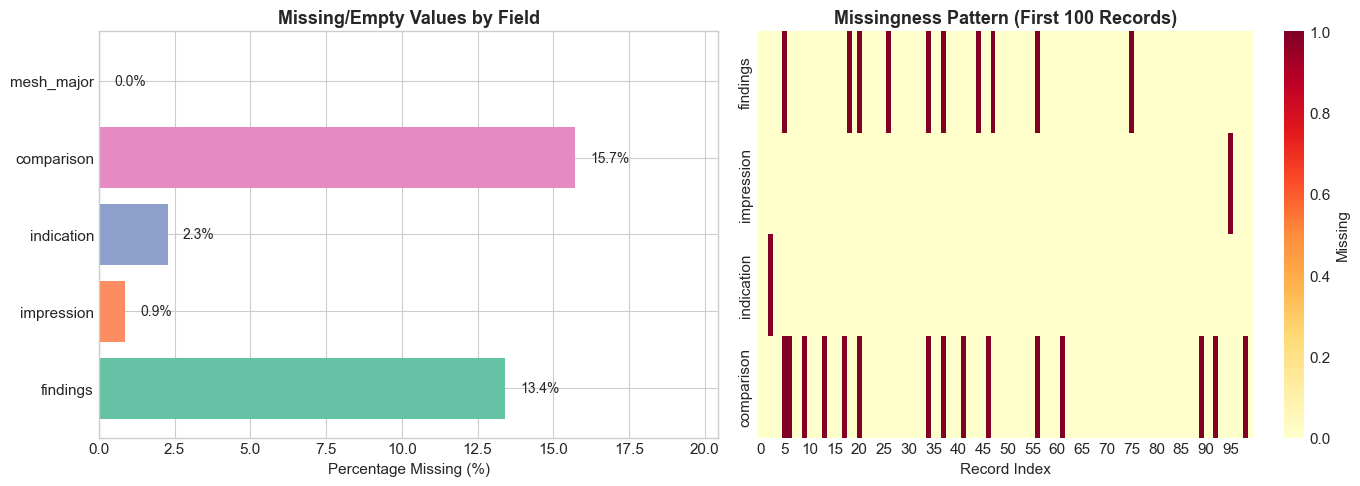


Missing Data Summary:
            missing  pct_missing
findings        530         13.4
impression       34          0.9
indication       90          2.3
comparison      622         15.7
mesh_major        0          0.0


In [5]:
# Missing value analysis
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count missing/empty
missing_data = {}
for col in ['findings', 'impression', 'indication', 'comparison', 'mesh_major']:
    empty = df[col].isna() | (df[col] == '')
    missing_data[col] = {'missing': empty.sum(), 'present': len(df) - empty.sum()}

missing_df = pd.DataFrame(missing_data).T
missing_df['pct_missing'] = 100 * missing_df['missing'] / len(df)

# Bar chart
ax = axes[0]
bars = ax.barh(missing_df.index, missing_df['pct_missing'], color=sns.color_palette('Set2'))
ax.set_xlabel('Percentage Missing (%)')
ax.set_title('Missing/Empty Values by Field', fontsize=13, fontweight='bold')
for i, v in enumerate(missing_df['pct_missing']):
    ax.text(v + 0.5, i, f'{v:.1f}%', va='center', fontsize=10)
ax.set_xlim(0, max(missing_df['pct_missing']) * 1.3)

# Heatmap of missingness pattern
ax = axes[1]
miss_matrix = df[['findings', 'impression', 'indication', 'comparison']].apply(
    lambda x: x.isna() | (x == ''))
sns.heatmap(miss_matrix.head(100).T.astype(int), cmap='YlOrRd', cbar_kws={'label': 'Missing'},
            ax=ax, yticklabels=True)
ax.set_title('Missingness Pattern (First 100 Records)', fontsize=13, fontweight='bold')
ax.set_xlabel('Record Index')

plt.tight_layout()
plt.savefig('../outputs/01_missing_data_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nMissing Data Summary:")
print(missing_df[['missing', 'pct_missing']].round(1).to_string())


## 4. Report Length Distribution

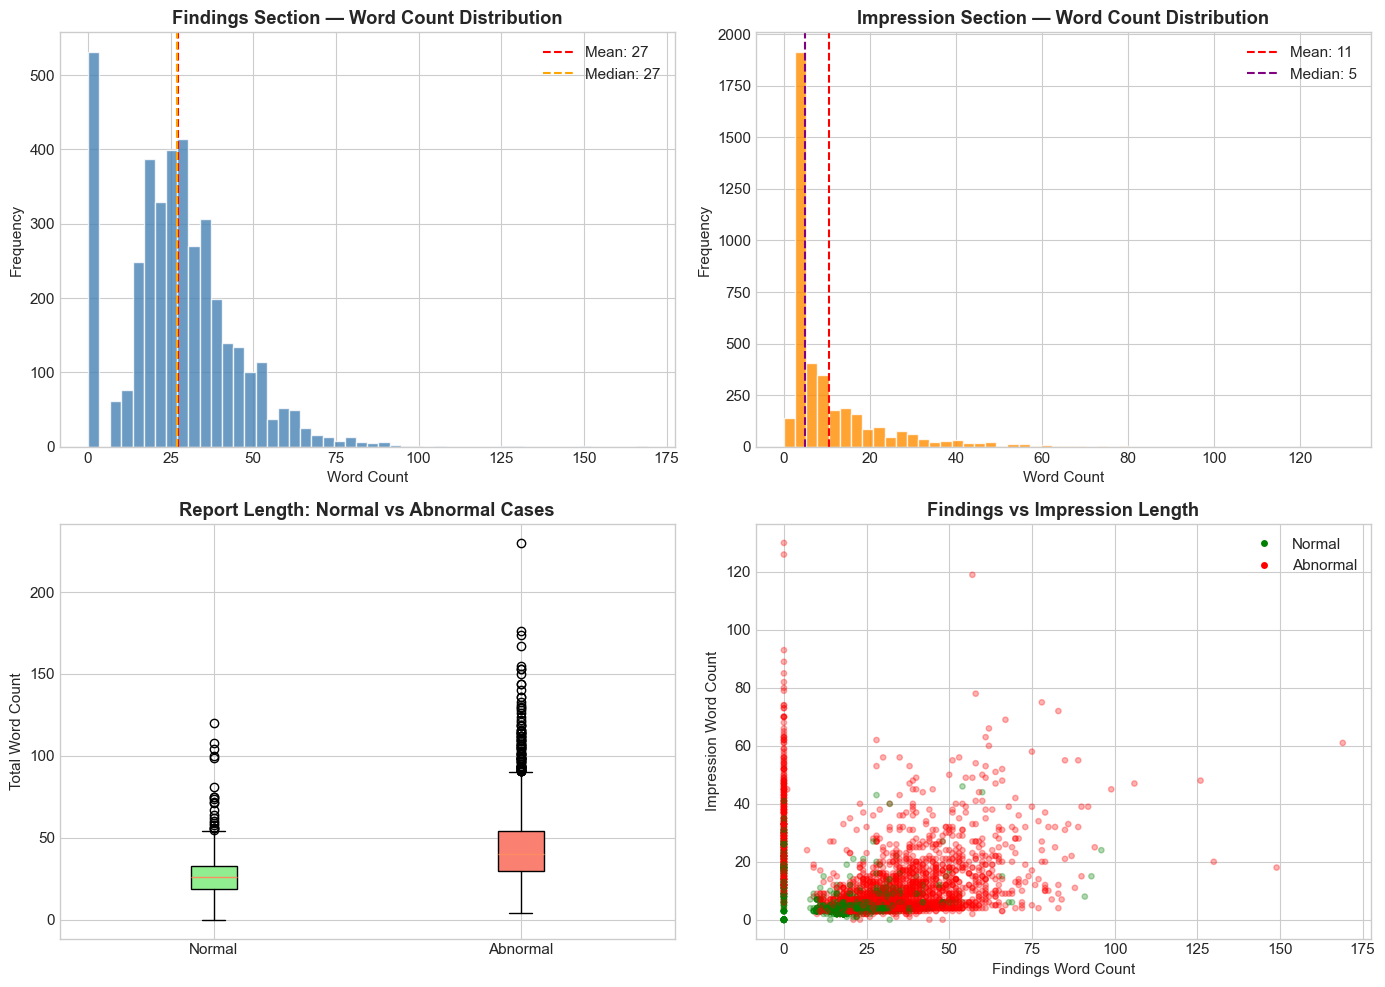

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Findings word count distribution
ax = axes[0, 0]
ax.hist(df['findings_word_count'], bins=50, color='steelblue', edgecolor='white', alpha=0.8)
ax.axvline(df['findings_word_count'].mean(), color='red', linestyle='--', label=f"Mean: {df['findings_word_count'].mean():.0f}")
ax.axvline(df['findings_word_count'].median(), color='orange', linestyle='--', label=f"Median: {df['findings_word_count'].median():.0f}")
ax.set_xlabel('Word Count')
ax.set_ylabel('Frequency')
ax.set_title('Findings Section — Word Count Distribution', fontweight='bold')
ax.legend()

# Impression word count distribution
ax = axes[0, 1]
ax.hist(df['impression_word_count'], bins=50, color='darkorange', edgecolor='white', alpha=0.8)
ax.axvline(df['impression_word_count'].mean(), color='red', linestyle='--', label=f"Mean: {df['impression_word_count'].mean():.0f}")
ax.axvline(df['impression_word_count'].median(), color='purple', linestyle='--', label=f"Median: {df['impression_word_count'].median():.0f}")
ax.set_xlabel('Word Count')
ax.set_ylabel('Frequency')
ax.set_title('Impression Section — Word Count Distribution', fontweight='bold')
ax.legend()

# Total length boxplot by category
ax = axes[1, 0]
# Create a simple normal/abnormal split
df['is_normal'] = df['mesh_major'].apply(lambda x: 'normal' in str(x).lower() and '|' not in str(x))
groups = df.groupby('is_normal')['total_word_count']
data_box = [df[df['is_normal']]['total_word_count'].values, df[~df['is_normal']]['total_word_count'].values]
bp = ax.boxplot(data_box, labels=['Normal', 'Abnormal'], patch_artist=True)
bp['boxes'][0].set_facecolor('lightgreen')
bp['boxes'][1].set_facecolor('salmon')
ax.set_ylabel('Total Word Count')
ax.set_title('Report Length: Normal vs Abnormal Cases', fontweight='bold')

# Scatter: Findings vs Impression length
ax = axes[1, 1]
scatter = ax.scatter(df['findings_word_count'], df['impression_word_count'], 
                     alpha=0.3, c=df['is_normal'].map({True:'green', False:'red'}), s=15)
ax.set_xlabel('Findings Word Count')
ax.set_ylabel('Impression Word Count')
ax.set_title('Findings vs Impression Length', fontweight='bold')
ax.legend(handles=[plt.Line2D([0],[0],marker='o',color='w',markerfacecolor='green',label='Normal'),
                   plt.Line2D([0],[0],marker='o',color='w',markerfacecolor='red',label='Abnormal')])

plt.tight_layout()
plt.savefig('../outputs/02_report_length_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


## 5. Pathology Category Analysis

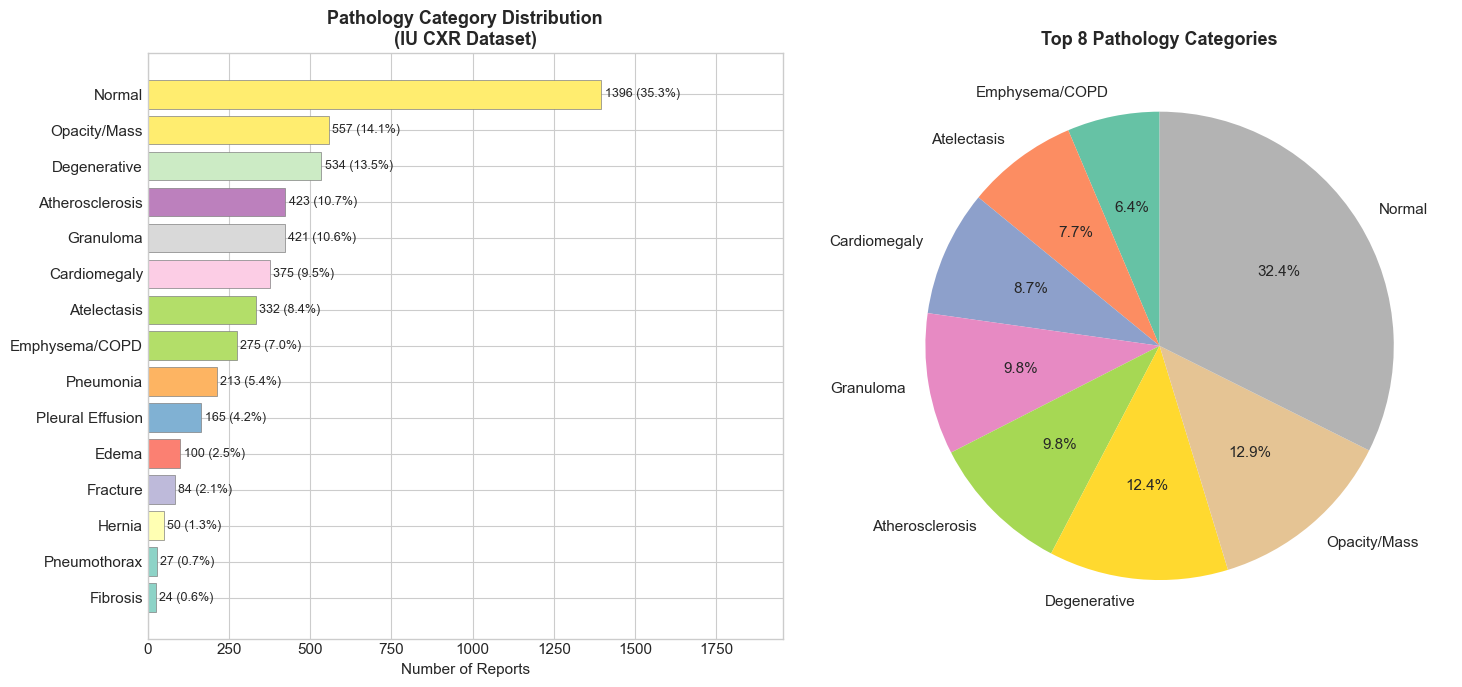


Pathology Category Counts:
                  count  percentage
Normal             1396   35.297092
Opacity/Mass        557   14.083439
Degenerative        534   13.501896
Atherosclerosis     423   10.695322
Granuloma           421   10.644753
Cardiomegaly        375    9.481669
Atelectasis         332    8.394437
Emphysema/COPD      275    6.953224
Pneumonia           213    5.385588
Pleural Effusion    165    4.171934
Edema               100    2.528445
Fracture             84    2.123894
Hernia               50    1.264223
Pneumothorax         27    0.682680
Fibrosis             24    0.606827


In [7]:
# Map MeSH terms to clinical pathology categories
pathology_map = {
    'Normal': ['normal'],
    'Cardiomegaly': ['cardiomegaly'],
    'Opacity/Mass': ['opacity', 'mass', 'nodule', 'lesion'],
    'Atelectasis': ['atelectasis'],
    'Pleural Effusion': ['pleural effusion', 'effusion'],
    'Pneumonia': ['pneumonia', 'consolidation', 'infiltrate', 'airspace disease'],
    'Emphysema/COPD': ['emphysema', 'copd', 'pulmonary disease, chronic obstructive', 'hyperdistention'],
    'Edema': ['edema', 'pulmonary congestion', 'congestion'],
    'Fracture': ['fracture'],
    'Pneumothorax': ['pneumothorax'],
    'Degenerative': ['degenerative', 'spondylosis'],
    'Atherosclerosis': ['atherosclerosis', 'calcinos'],
    'Granuloma': ['granuloma'],
    'Hernia': ['hernia'],
    'Fibrosis': ['fibrosis', 'scarring']
}

# Assign categories
category_counts = {}
df['pathology_categories'] = ''

for idx, row in df.iterrows():
    mesh = str(row['mesh_major']).lower()
    cats = []
    for cat, keywords in pathology_map.items():
        if any(kw in mesh for kw in keywords):
            cats.append(cat)
    df.at[idx, 'pathology_categories'] = '|'.join(cats) if cats else 'Other'

for cat in pathology_map.keys():
    count = df['pathology_categories'].apply(lambda x: cat in x).sum()
    category_counts[cat] = count

cat_df = pd.DataFrame.from_dict(category_counts, orient='index', columns=['count'])
cat_df['percentage'] = 100 * cat_df['count'] / len(df)
cat_df = cat_df.sort_values('count', ascending=True)

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(15, 7))

# Horizontal bar chart
ax = axes[0]
colors = plt.cm.Set3(np.linspace(0, 1, len(cat_df)))
bars = ax.barh(cat_df.index, cat_df['count'], color=colors, edgecolor='gray', linewidth=0.5)
ax.set_xlabel('Number of Reports')
ax.set_title('Pathology Category Distribution\n(IU CXR Dataset)', fontsize=13, fontweight='bold')
for i, (cnt, pct) in enumerate(zip(cat_df['count'], cat_df['percentage'])):
    ax.text(cnt + 10, i, f'{cnt} ({pct:.1f}%)', va='center', fontsize=9)
ax.set_xlim(0, cat_df['count'].max() * 1.4)

# Pie chart for top categories
ax = axes[1]
top_cats = cat_df.tail(8)
wedges, texts, autotexts = ax.pie(top_cats['count'], labels=top_cats.index, 
                                    autopct='%1.1f%%', startangle=90,
                                    colors=plt.cm.Set2(np.linspace(0, 1, len(top_cats))))
ax.set_title('Top 8 Pathology Categories', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('../outputs/03_pathology_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nPathology Category Counts:")
print(cat_df.sort_values('count', ascending=False).to_string())


## 6. Pathology Co-occurrence Analysis

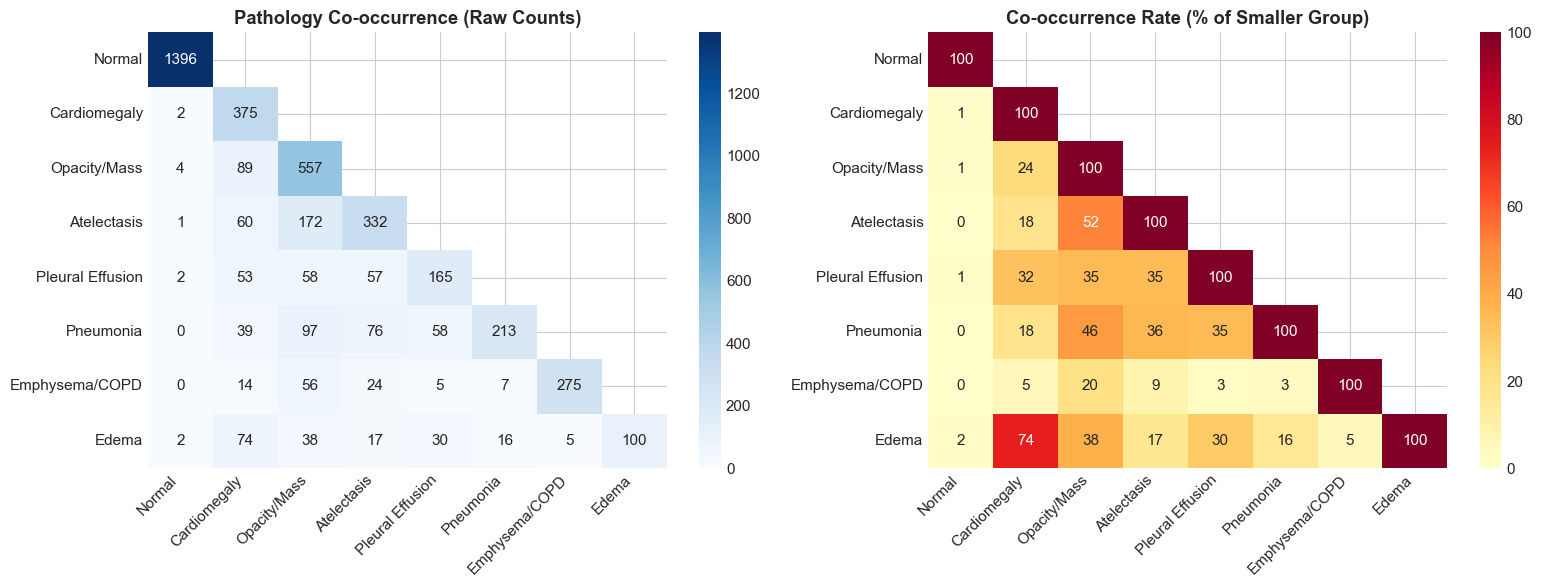

In [8]:
# Build co-occurrence matrix
main_categories = ['Normal', 'Cardiomegaly', 'Opacity/Mass', 'Atelectasis', 
                   'Pleural Effusion', 'Pneumonia', 'Emphysema/COPD', 'Edema']

# Create binary indicators
for cat in main_categories:
    df[f'has_{cat}'] = df['pathology_categories'].apply(lambda x: 1 if cat in x else 0)

binary_cols = [f'has_{cat}' for cat in main_categories]
cooccurrence = df[binary_cols].T.dot(df[binary_cols])

# Normalize to percentages (of smaller group)
cooccurrence_pct = cooccurrence.copy().astype(float)
for i in range(len(main_categories)):
    for j in range(len(main_categories)):
        min_count = min(cooccurrence.iloc[i, i], cooccurrence.iloc[j, j])
        if min_count > 0:
            cooccurrence_pct.iloc[i, j] = 100 * cooccurrence.iloc[i, j] / min_count
        else:
            cooccurrence_pct.iloc[i, j] = 0

cooccurrence_pct.columns = main_categories
cooccurrence_pct.index = main_categories

# Plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Raw counts
ax = axes[0]
mask = np.triu(np.ones_like(cooccurrence, dtype=bool), k=1)
sns.heatmap(cooccurrence, mask=mask, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=main_categories, yticklabels=main_categories)
ax.set_title('Pathology Co-occurrence (Raw Counts)', fontweight='bold')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

# Percentage
ax = axes[1]
mask = np.triu(np.ones_like(cooccurrence_pct, dtype=bool), k=1)
sns.heatmap(cooccurrence_pct, mask=mask, annot=True, fmt='.0f', cmap='YlOrRd', ax=ax,
            xticklabels=main_categories, yticklabels=main_categories,
            vmin=0, vmax=100)
ax.set_title('Co-occurrence Rate (% of Smaller Group)', fontweight='bold')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.savefig('../outputs/04_cooccurrence_matrix.png', dpi=150, bbox_inches='tight')
plt.show()


## 7. MeSH Terms & Word Cloud Analysis

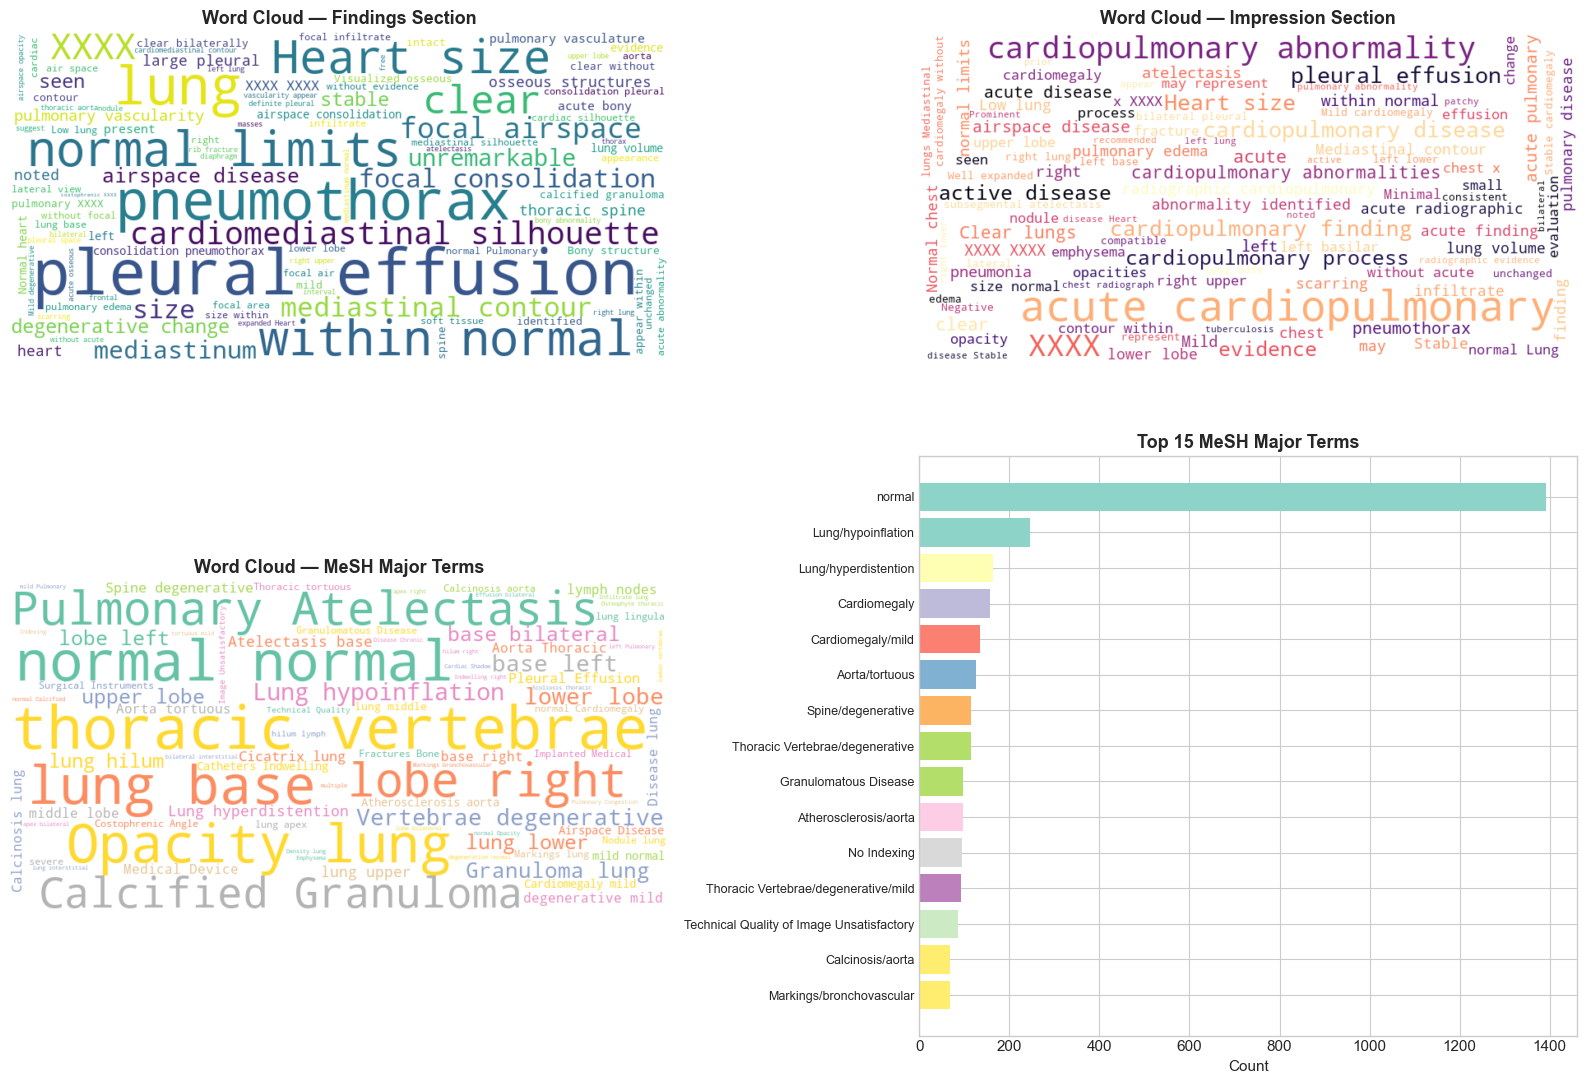

In [9]:
# Word clouds for findings and impressions
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Findings word cloud
findings_text = ' '.join(df['findings'].dropna().tolist())
wc = WordCloud(width=800, height=400, background_color='white', 
               colormap='viridis', max_words=100).generate(findings_text)
axes[0, 0].imshow(wc, interpolation='bilinear')
axes[0, 0].set_title('Word Cloud — Findings Section', fontsize=13, fontweight='bold')
axes[0, 0].axis('off')

# Impression word cloud
impression_text = ' '.join(df['impression'].dropna().tolist())
wc2 = WordCloud(width=800, height=400, background_color='white',
                colormap='magma', max_words=100).generate(impression_text)
axes[0, 1].imshow(wc2, interpolation='bilinear')
axes[0, 1].set_title('Word Cloud — Impression Section', fontsize=13, fontweight='bold')
axes[0, 1].axis('off')

# MeSH terms word cloud
mesh_text = ' '.join(df['mesh_major'].dropna().tolist()).replace('|', ' ')
wc3 = WordCloud(width=800, height=400, background_color='white',
                colormap='Set2', max_words=80).generate(mesh_text)
axes[1, 0].imshow(wc3, interpolation='bilinear')
axes[1, 0].set_title('Word Cloud — MeSH Major Terms', fontsize=13, fontweight='bold')
axes[1, 0].axis('off')

# Top MeSH terms bar
all_mesh = []
for m in df['mesh_major'].dropna():
    if m:
        all_mesh.extend(m.split('|'))
mesh_counts = pd.Series(all_mesh).value_counts().head(15)
axes[1, 1].barh(range(len(mesh_counts)), mesh_counts.values, color=plt.cm.Set3(np.linspace(0,1,15)))
axes[1, 1].set_yticks(range(len(mesh_counts)))
axes[1, 1].set_yticklabels(mesh_counts.index, fontsize=9)
axes[1, 1].set_xlabel('Count')
axes[1, 1].set_title('Top 15 MeSH Major Terms', fontsize=13, fontweight='bold')
axes[1, 1].invert_yaxis()

plt.tight_layout()
plt.savefig('../outputs/05_wordclouds_mesh.png', dpi=150, bbox_inches='tight')
plt.show()


## 8. Text Quality Assessment

In [10]:
# Analyze text quality issues
print("=" * 60)
print("TEXT QUALITY ASSESSMENT")
print("=" * 60)

# Check for XXXX placeholders (anonymization)
df['has_xxxx'] = df['findings'].fillna('').apply(lambda x: 'XXXX' in x.upper()) | \
                 df['impression'].fillna('').apply(lambda x: 'XXXX' in x.upper())
print(f"\nRecords with 'XXXX' placeholder: {df['has_xxxx'].sum()} ({100*df['has_xxxx'].mean():.1f}%)")

# Very short reports (< 5 words in findings)
very_short = df['findings_word_count'] < 5
print(f"Very short findings (<5 words): {very_short.sum()} ({100*very_short.mean():.1f}%)")

# Very long reports
very_long = df['total_word_count'] > 100
print(f"Very long reports (>100 words): {very_long.sum()} ({100*very_long.mean():.1f}%)")

# Reports exceeding BERT 512 token limit (approx 1.3 tokens per word)
approx_tokens = df['total_word_count'] * 1.3
exceeds_512 = approx_tokens > 512
print(f"Reports exceeding ~512 tokens: {exceeds_512.sum()} ({100*exceeds_512.mean():.1f}%)")

# Sentence structure analysis
df['avg_sentence_len'] = df.apply(
    lambda r: r['findings_word_count']/max(r['findings_sentence_count'],1), axis=1)

print(f"\nAverage sentence length in Findings:")
print(f"  Mean: {df['avg_sentence_len'].mean():.1f} words")
print(f"  Median: {df['avg_sentence_len'].median():.1f} words")

# Number of unique vocabularies
from collections import Counter
all_words_findings = ' '.join(df['findings'].dropna()).lower().split()
all_words_impression = ' '.join(df['impression'].dropna()).lower().split()
print(f"\nVocabulary Size:")
print(f"  Findings: {len(set(all_words_findings)):,} unique words from {len(all_words_findings):,} total")
print(f"  Impression: {len(set(all_words_impression)):,} unique words from {len(all_words_impression):,} total")

# Multi-label report stats
df['num_pathologies'] = df['pathology_categories'].apply(lambda x: len(x.split('|')) if x != 'Other' else 0)
print(f"\nMulti-label Statistics:")
print(f"  Mean pathologies per report: {df['num_pathologies'].mean():.2f}")
print(f"  Reports with 2+ pathologies: {(df['num_pathologies']>=2).sum()} ({100*(df['num_pathologies']>=2).mean():.1f}%)")
print(f"  Reports with 3+ pathologies: {(df['num_pathologies']>=3).sum()} ({100*(df['num_pathologies']>=3).mean():.1f}%)")


TEXT QUALITY ASSESSMENT

Records with 'XXXX' placeholder: 1855 (46.9%)
Very short findings (<5 words): 531 (13.4%)
Very long reports (>100 words): 60 (1.5%)
Reports exceeding ~512 tokens: 0 (0.0%)

Average sentence length in Findings:
  Mean: 5.9 words
  Median: 6.2 words

Vocabulary Size:
  Findings: 2,450 unique words from 108,395 total
  Impression: 2,265 unique words from 41,832 total

Multi-label Statistics:
  Mean pathologies per report: 1.26
  Reports with 2+ pathologies: 992 (25.1%)
  Reports with 3+ pathologies: 406 (10.3%)


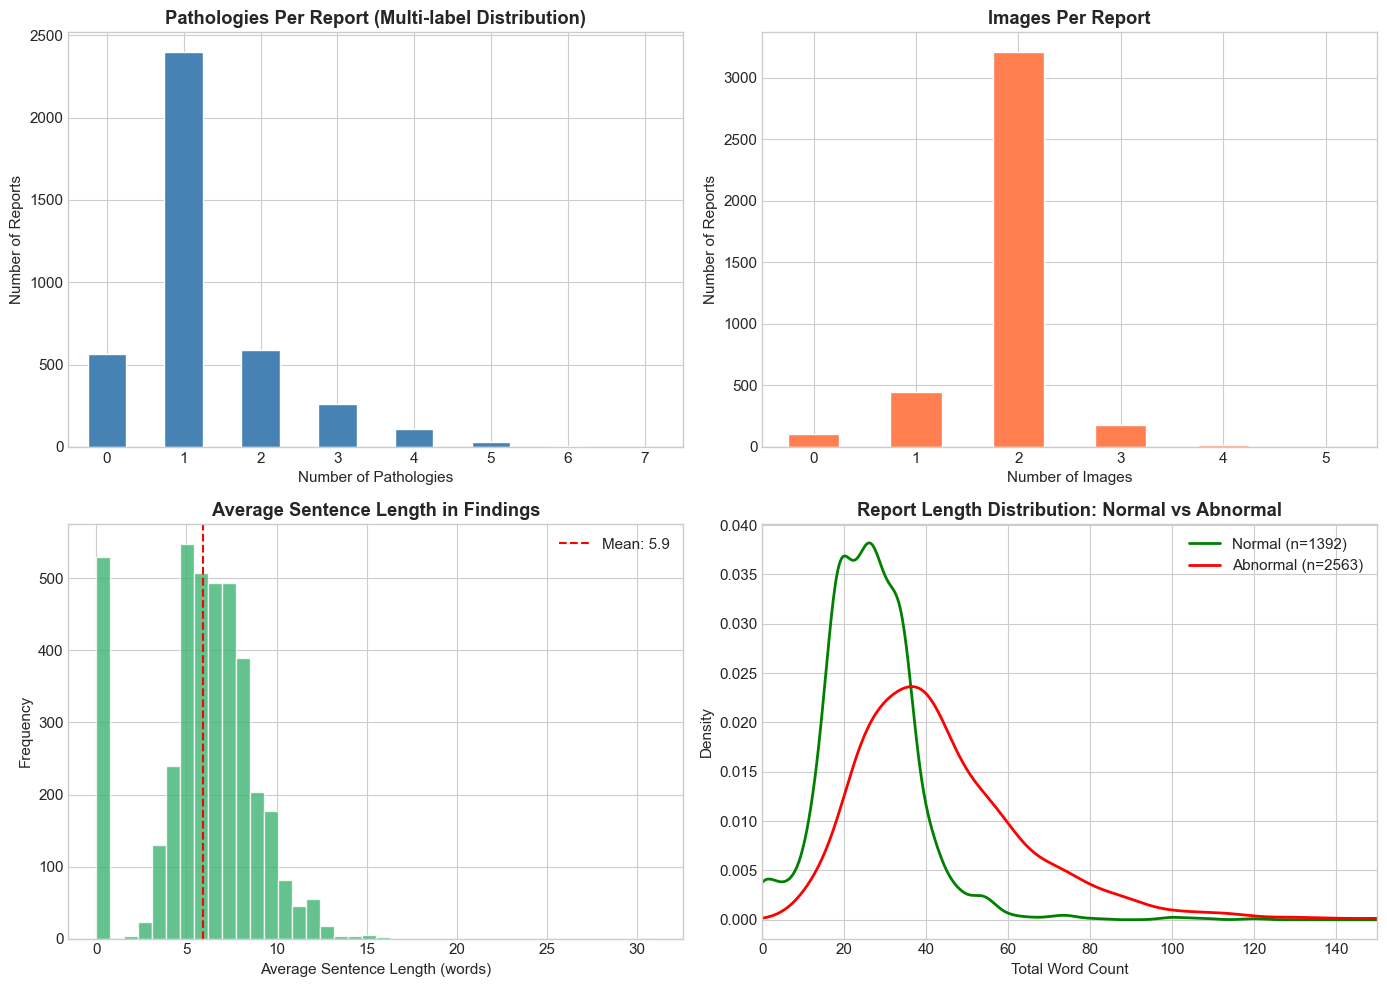

In [11]:
# Visualization of quality metrics
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Distribution of pathologies per report
ax = axes[0, 0]
df['num_pathologies'].value_counts().sort_index().plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_xlabel('Number of Pathologies')
ax.set_ylabel('Number of Reports')
ax.set_title('Pathologies Per Report (Multi-label Distribution)', fontweight='bold')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)

# Images per report
ax = axes[0, 1]
df['num_images'].value_counts().sort_index().plot(kind='bar', ax=ax, color='coral', edgecolor='white')
ax.set_xlabel('Number of Images')
ax.set_ylabel('Number of Reports')
ax.set_title('Images Per Report', fontweight='bold')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)

# Sentence length distribution
ax = axes[1, 0]
ax.hist(df['avg_sentence_len'].dropna(), bins=40, color='mediumseagreen', edgecolor='white', alpha=0.8)
ax.set_xlabel('Average Sentence Length (words)')
ax.set_ylabel('Frequency')
ax.set_title('Average Sentence Length in Findings', fontweight='bold')
ax.axvline(df['avg_sentence_len'].mean(), color='red', linestyle='--', label=f"Mean: {df['avg_sentence_len'].mean():.1f}")
ax.legend()

# KDE: Normal vs Abnormal report length
ax = axes[1, 1]
normal_lens = df[df['is_normal']]['total_word_count']
abnormal_lens = df[~df['is_normal']]['total_word_count']
normal_lens.plot(kind='kde', ax=ax, label=f'Normal (n={len(normal_lens)})', color='green', linewidth=2)
abnormal_lens.plot(kind='kde', ax=ax, label=f'Abnormal (n={len(abnormal_lens)})', color='red', linewidth=2)
ax.set_xlabel('Total Word Count')
ax.set_ylabel('Density')
ax.set_title('Report Length Distribution: Normal vs Abnormal', fontweight='bold')
ax.legend()
ax.set_xlim(0, 150)

plt.tight_layout()
plt.savefig('../outputs/06_text_quality.png', dpi=150, bbox_inches='tight')
plt.show()


## 9. Advanced Statistical Analysis - Distribution Properties


In [12]:
from scipy import stats
import matplotlib.gridspec as gridspec

# Compute distribution properties
print("=" * 70)
print("DISTRIBUTION PROPERTIES & NORMALITY TESTS")
print("=" * 70)

distributions_to_analyze = {
    'Findings Word Count': df['findings_word_count'],
    'Impression Word Count': df['impression_word_count'],
    'Total Word Count': df['total_word_count'],
    'Sentence Count': df['findings_sentence_count'],
    'Avg Sentence Length': df['avg_sentence_len'].fillna(0)
}

summary_stats = []
for name, series in distributions_to_analyze.items():
    valid_data = series[series > 0]
    
    # Normality tests
    stat_shapiro, p_shapiro = stats.shapiro(valid_data.sample(min(5000, len(valid_data))))
    stat_ks, p_ks = stats.kstest(valid_data, 'norm', args=(valid_data.mean(), valid_data.std()))
    
    summary_stats.append({
        'Metric': name,
        'Mean': valid_data.mean(),
        'Median': valid_data.median(),
        'Std Dev': valid_data.std(),
        'Skewness': stats.skew(valid_data),
        'Kurtosis': stats.kurtosis(valid_data),
        'Min': valid_data.min(),
        'Max': valid_data.max(),
        'Q1': valid_data.quantile(0.25),
        'Q3': valid_data.quantile(0.75),
        'IQR': valid_data.quantile(0.75) - valid_data.quantile(0.25)
    })

stats_df = pd.DataFrame(summary_stats)
print("\nDescriptive Statistics:")
print(stats_df.to_string(index=False))

print("\n\nNormality Tests (Shapiro-Wilk, p-value):")
for name, series in distributions_to_analyze.items():
    valid_data = series[series > 0]
    stat_shapiro, p_shapiro = stats.shapiro(valid_data.sample(min(5000, len(valid_data))))
    is_normal = "✓ Normal" if p_shapiro > 0.05 else "✗ Non-normal"
    print(f"  {name:30s}: p={p_shapiro:.4f} {is_normal}")


DISTRIBUTION PROPERTIES & NORMALITY TESTS

Descriptive Statistics:
               Metric      Mean  Median   Std Dev  Skewness  Kurtosis  Min   Max        Q1   Q3       IQR
  Findings Word Count 31.648175    29.0 14.627132  1.573385  5.735022  1.0 169.0 22.000000 38.0 16.000000
Impression Word Count 10.668707     5.0 12.061161  2.973138 12.795084  1.0 130.0  4.000000 12.0  8.000000
     Total Word Count 38.254902    34.0 20.433969  1.838441  6.378026  3.0 230.0 25.000000 46.5 21.500000
       Sentence Count  4.675328     4.0  1.671204  1.474385  4.936622  1.0  18.0  4.000000  5.0  1.000000
  Avg Sentence Length  6.799280     6.6  2.054358  1.142691  6.031050  1.0  31.0  5.333333  8.0  2.666667


Normality Tests (Shapiro-Wilk, p-value):
  Findings Word Count           : p=0.0000 ✗ Non-normal
  Impression Word Count         : p=0.0000 ✗ Non-normal
  Total Word Count              : p=0.0000 ✗ Non-normal
  Sentence Count                : p=0.0000 ✗ Non-normal
  Avg Sentence Length         

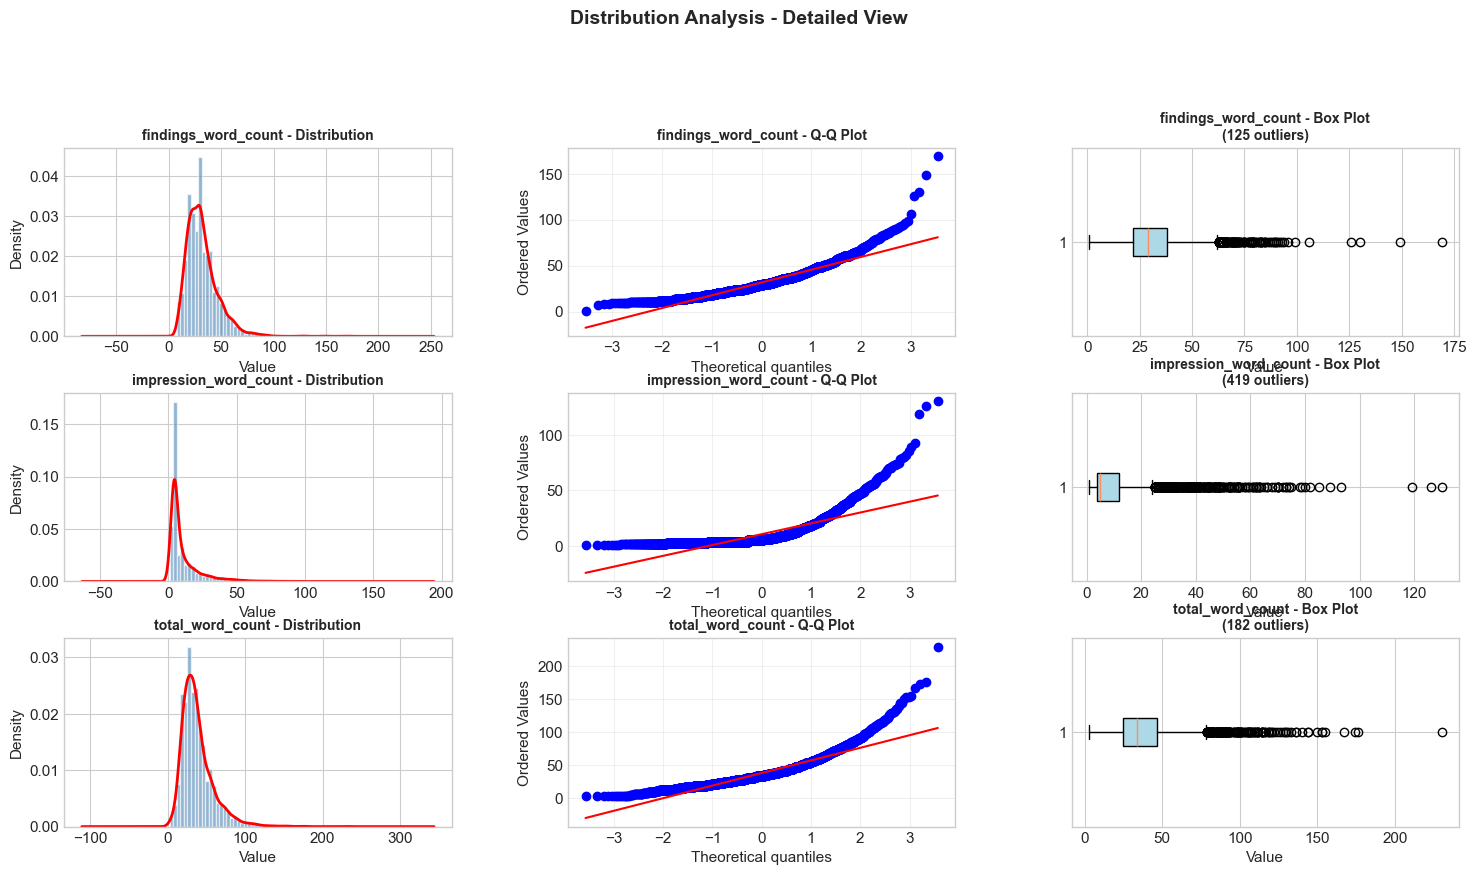

In [13]:
# Comprehensive Q-Q plots and distribution visualizations
fig = plt.figure(figsize=(18, 12))
gs = gridspec.GridSpec(4, 3, figure=fig, hspace=0.3, wspace=0.3)

cols = ['findings_word_count', 'impression_word_count', 'total_word_count']
row_idx = 0

for col in cols:
    data = df[col][df[col] > 0]
    
    # Histogram with KDE
    ax1 = fig.add_subplot(gs[row_idx, 0])
    ax1.hist(data, bins=50, density=True, alpha=0.6, color='steelblue', edgecolor='white')
    data.plot(kind='kde', ax=ax1, color='red', linewidth=2, secondary_y=False)
    ax1.set_title(f'{col} - Distribution', fontweight='bold', fontsize=10)
    ax1.set_xlabel('Value')
    
    # Q-Q plot
    ax2 = fig.add_subplot(gs[row_idx, 1])
    stats.probplot(data, dist="norm", plot=ax2)
    ax2.set_title(f'{col} - Q-Q Plot', fontweight='bold', fontsize=10)
    ax2.grid(True, alpha=0.3)
    
    # Box plot with outlier info
    ax3 = fig.add_subplot(gs[row_idx, 2])
    Q1, Q3 = data.quantile([0.25, 0.75])
    IQR = Q3 - Q1
    outliers = data[(data < Q1 - 1.5*IQR) | (data > Q3 + 1.5*IQR)]
    bp = ax3.boxplot(data, vert=False, patch_artist=True)
    bp['boxes'][0].set_facecolor('lightblue')
    ax3.set_title(f'{col} - Box Plot\n({len(outliers)} outliers)', fontweight='bold', fontsize=10)
    ax3.set_xlabel('Value')
    
    row_idx += 1

plt.suptitle('Distribution Analysis - Detailed View', fontsize=14, fontweight='bold', y=0.995)
plt.savefig('../outputs/07_distribution_analysis.png', dpi=150, bbox_inches='tight')
plt.show()


## 10. Correlation & Feature Relationships


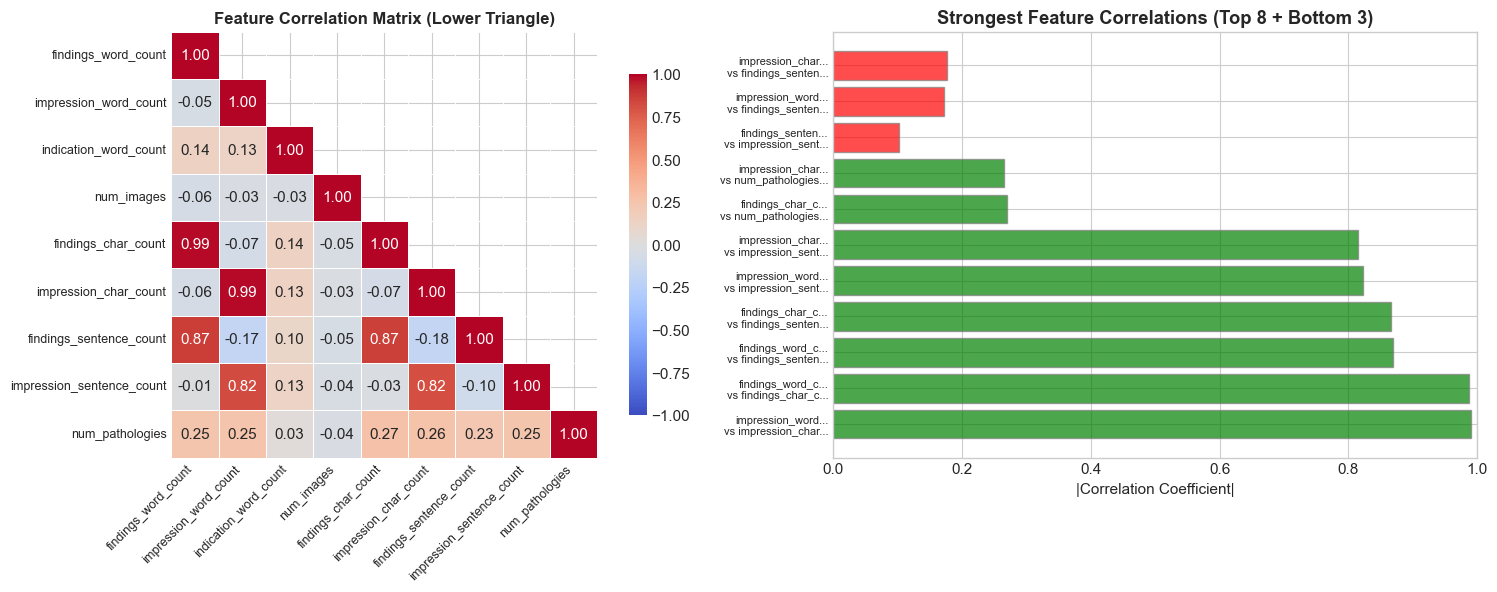


Top 10 Feature Correlations:
            Feature 1                 Feature 2  Correlation
impression_word_count     impression_char_count     0.990639
  findings_word_count       findings_char_count     0.986926
  findings_word_count   findings_sentence_count     0.869160
  findings_char_count   findings_sentence_count     0.865526
impression_word_count impression_sentence_count     0.823111
impression_char_count impression_sentence_count     0.815234
  findings_char_count           num_pathologies     0.269146
impression_char_count           num_pathologies     0.264489
impression_word_count           num_pathologies     0.251837
  findings_word_count           num_pathologies     0.248445


In [14]:
# Feature correlation matrix
numeric_cols = ['findings_word_count', 'impression_word_count', 'indication_word_count',
                'num_images', 'findings_char_count', 'impression_char_count', 
                'findings_sentence_count', 'impression_sentence_count', 'num_pathologies']

correlation_matrix = df[numeric_cols].corr()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Heatmap
ax = axes[0]
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool), k=1)
sns.heatmap(correlation_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, ax=ax, square=True, linewidths=0.5, cbar_kws={"shrink": 0.8},
            vmin=-1, vmax=1)
ax.set_title('Feature Correlation Matrix (Lower Triangle)', fontsize=12, fontweight='bold')
plt.setp(ax.get_xticklabels(), rotation=45, ha='right', fontsize=9)
plt.setp(ax.get_yticklabels(), fontsize=9)

# Strongest correlations
ax = axes[1]
corr_pairs = []
for i in range(len(correlation_matrix)):
    for j in range(i+1, len(correlation_matrix)):
        corr_pairs.append({
            'Feature 1': correlation_matrix.index[i],
            'Feature 2': correlation_matrix.columns[j],
            'Correlation': correlation_matrix.iloc[i, j]
        })
corr_pairs_df = pd.DataFrame(corr_pairs).sort_values('Correlation', ascending=False)
top_corrs = pd.concat([corr_pairs_df.head(8), corr_pairs_df.tail(3)])
y_pos = np.arange(len(top_corrs))
colors = ['green' if x > 0 else 'red' for x in top_corrs['Correlation']]
ax.barh(y_pos, top_corrs['Correlation'].abs(), color=colors, alpha=0.7, edgecolor='gray')
labels = [f"{r['Feature 1'][:15]}...\nvs {r['Feature 2'][:15]}..." for _, r in top_corrs.iterrows()]
ax.set_yticks(y_pos)
ax.set_yticklabels(labels, fontsize=8)
ax.set_xlabel('|Correlation Coefficient|')
ax.set_title('Strongest Feature Correlations (Top 8 + Bottom 3)', fontweight='bold')
ax.set_xlim(0, 1)

plt.tight_layout()
plt.savefig('../outputs/08_feature_correlations.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nTop 10 Feature Correlations:")
print(corr_pairs_df.head(10).to_string(index=False))


## 11. Violin Plots & Distribution Comparisons by Category


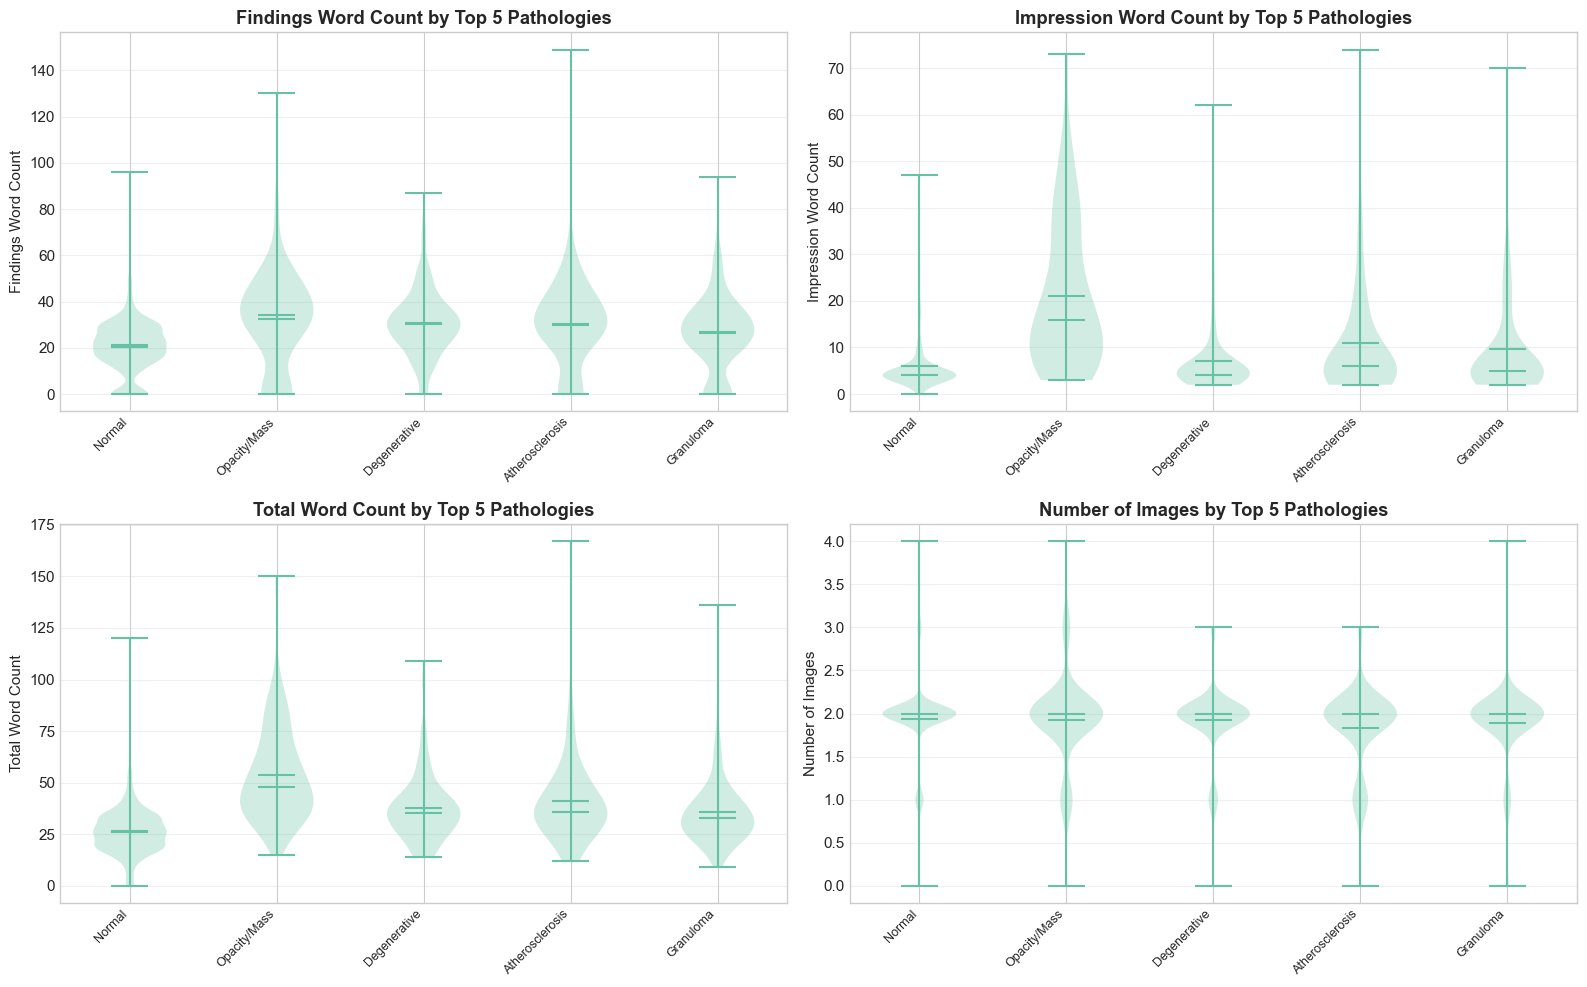

In [15]:
# Violin plots for metric distributions by pathology category
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Prepare data for top categories
top_categories = cat_df.nlargest(5, 'count').index.tolist()
df_plot = df[df['pathology_categories'].isin(top_categories)].copy()

metrics = ['findings_word_count', 'impression_word_count', 'total_word_count', 'num_images']
titles = ['Findings Word Count', 'Impression Word Count', 'Total Word Count', 'Number of Images']

for idx, (metric, title) in enumerate(zip(metrics, titles)):
    ax = axes[idx // 2, idx % 2]
    
    # Create violin plot
    parts = ax.violinplot([df_plot[df_plot['pathology_categories'] == cat][metric].dropna().values 
                           for cat in top_categories],
                          positions=range(len(top_categories)), showmeans=True, showmedians=True)
    
    ax.set_xticks(range(len(top_categories)))
    ax.set_xticklabels(top_categories, rotation=45, ha='right', fontsize=9)
    ax.set_ylabel(title)
    ax.set_title(f'{title} by Top 5 Pathologies', fontweight='bold')
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/09_violin_distributions_by_category.png', dpi=150, bbox_inches='tight')
plt.show()


## 12. Cumulative Distribution & Percentile Analysis


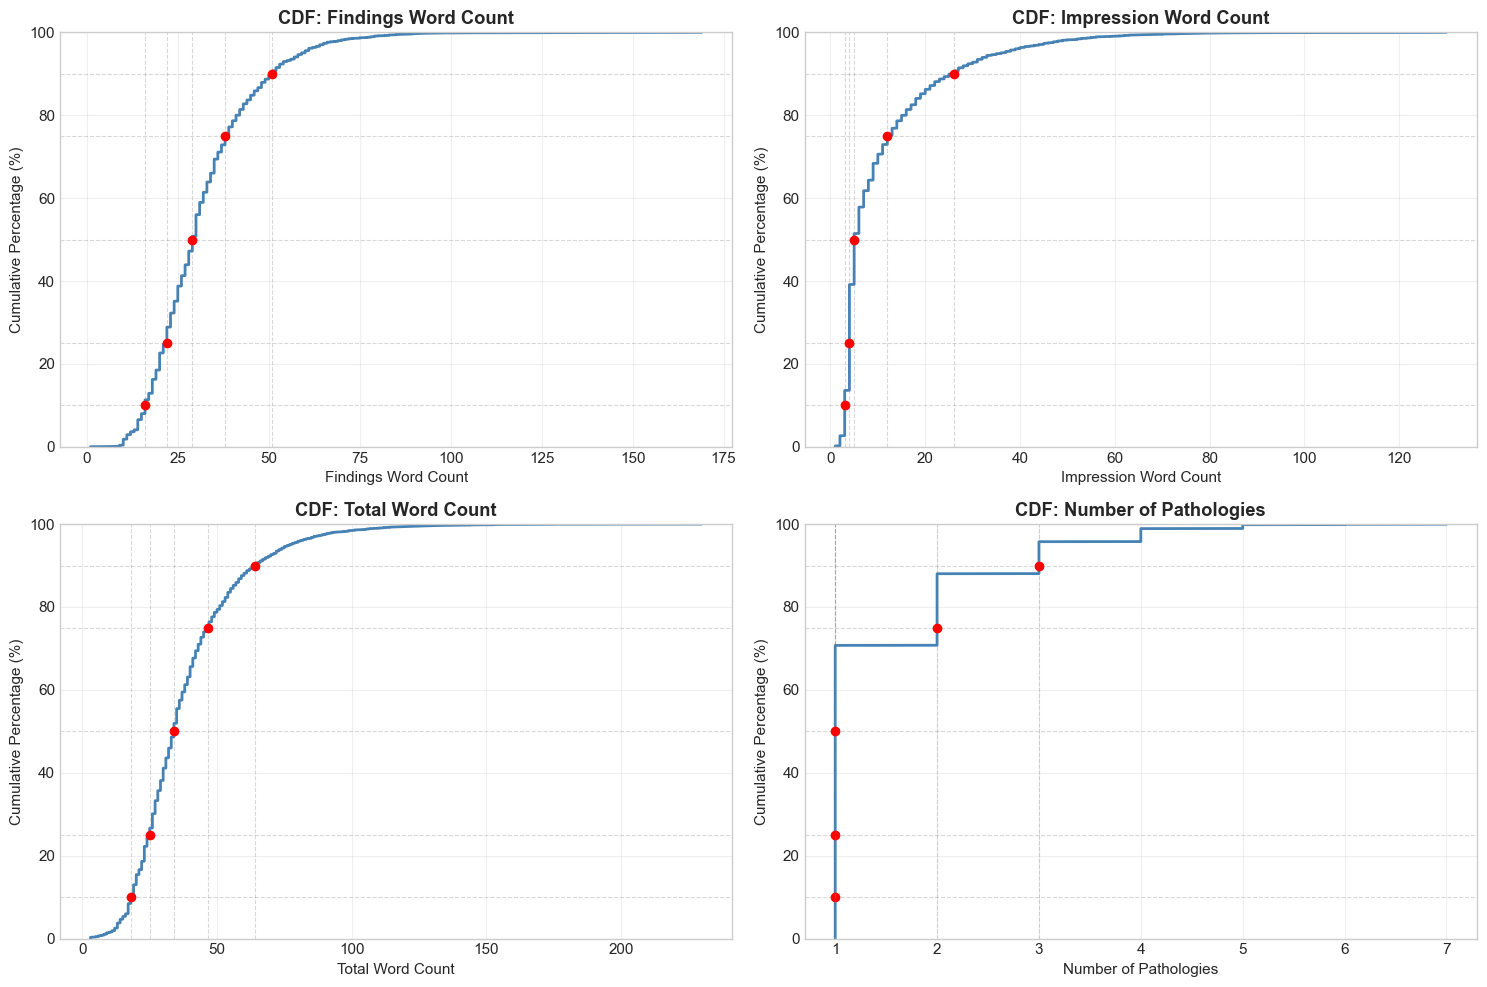

PERCENTILE ANALYSIS

     Findings Word Count  Impression Word Count  Total Word Count  Number of Pathologies
5%                  14.0                    3.0              15.0                    1.0
10%                 16.0                    3.0              18.0                    1.0
25%                 22.0                    4.0              25.0                    1.0
50%                 29.0                    5.0              34.0                    1.0
75%                 38.0                   12.0              46.5                    2.0
90%                 51.0                   26.0              64.0                    3.0
95%                 59.0                   36.0              77.0                    3.0
99%                 79.0                   58.8             109.7                    5.0


In [16]:
# Cumulative distribution and percentile analysis
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

metrics = [
    ('findings_word_count', 'Findings Word Count'),
    ('impression_word_count', 'Impression Word Count'),
    ('total_word_count', 'Total Word Count'),
    ('num_pathologies', 'Number of Pathologies')
]

for idx, (metric, title) in enumerate(metrics):
    ax = axes[idx // 2, idx % 2]
    
    data = df[metric][df[metric] > 0].sort_values()
    cumulative = np.arange(1, len(data) + 1) / len(data) * 100
    
    ax.plot(data.values, cumulative, linewidth=2, color='steelblue')
    
    # Mark percentiles
    percentiles = [10, 25, 50, 75, 90]
    for p in percentiles:
        val = np.percentile(data, p)
        ax.axhline(p, color='gray', linestyle='--', alpha=0.3, linewidth=0.8)
        ax.axvline(val, color='gray', linestyle='--', alpha=0.3, linewidth=0.8)
        ax.plot(val, p, 'ro', markersize=6)
    
    ax.set_xlabel(title)
    ax.set_ylabel('Cumulative Percentage (%)')
    ax.set_title(f'CDF: {title}', fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.set_ylim(0, 100)

plt.tight_layout()
plt.savefig('../outputs/10_cumulative_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

# Print percentile table
print("=" * 80)
print("PERCENTILE ANALYSIS")
print("=" * 80)

percentiles_list = [5, 10, 25, 50, 75, 90, 95, 99]
perc_table = {}

for metric, title in metrics:
    data = df[metric][df[metric] > 0]
    perc_vals = [np.percentile(data, p) for p in percentiles_list]
    perc_table[title] = perc_vals

perc_df = pd.DataFrame(perc_table, index=[f'{p}%' for p in percentiles_list])
print("\n" + perc_df.round(1).to_string())


## 13. Outlier Detection & Analysis


OUTLIER DETECTION - IQR METHOD

findings_word_count:
  IQR bounds: [-10.5, 65.5]
  Outliers: 91 (2.3%)

impression_word_count:
  IQR bounds: [-8.0, 24.0]
  Outliers: 419 (10.6%)

num_pathologies:
  IQR bounds: [-0.5, 3.5]
  Outliers: 144 (3.6%)

num_images:
  IQR bounds: [2.0, 2.0]
  Outliers: 747 (18.9%)


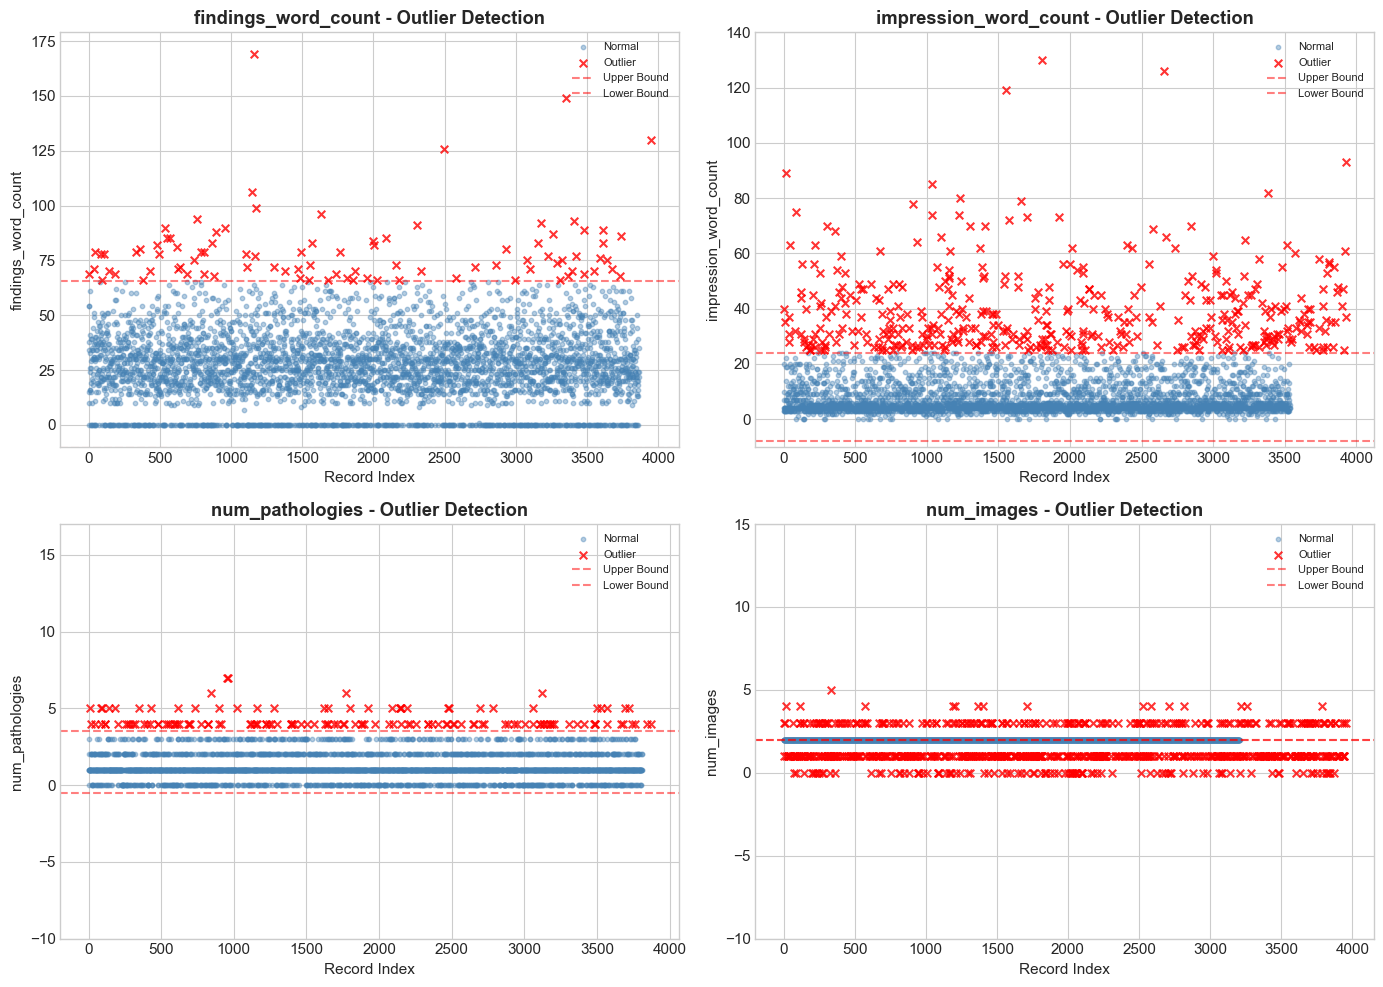

In [17]:
from sklearn.preprocessing import StandardScaler
from scipy.spatial.distance import mahalanobis

# Identify outliers using IQR method
print("=" * 80)
print("OUTLIER DETECTION - IQR METHOD")
print("=" * 80)

features_for_outliers = ['findings_word_count', 'impression_word_count', 'num_pathologies', 'num_images']
outlier_info = {}

for feature in features_for_outliers:
    Q1 = df[feature].quantile(0.25)
    Q3 = df[feature].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[feature] < lower_bound) | (df[feature] > upper_bound)]
    outlier_info[feature] = {
        'count': len(outliers),
        'pct': 100 * len(outliers) / len(df),
        'lower': lower_bound,
        'upper': upper_bound
    }
    
    print(f"\n{feature}:")
    print(f"  IQR bounds: [{lower_bound:.1f}, {upper_bound:.1f}]")
    print(f"  Outliers: {len(outliers)} ({100*len(outliers)/len(df):.1f}%)")

# Visualization of outliers
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for idx, feature in enumerate(features_for_outliers):
    ax = axes[idx // 2, idx % 2]
    
    Q1 = df[feature].quantile(0.25)
    Q3 = df[feature].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers_mask = (df[feature] < lower_bound) | (df[feature] > upper_bound)
    
    ax.scatter(range(len(df[~outliers_mask])), df[~outliers_mask][feature], 
              alpha=0.4, s=10, c='steelblue', label='Normal')
    ax.scatter(df[outliers_mask].index, df[outliers_mask][feature], 
              alpha=0.8, s=30, c='red', marker='x', label='Outlier')
    
    ax.axhline(upper_bound, color='red', linestyle='--', alpha=0.5, label='Upper Bound')
    ax.axhline(lower_bound, color='red', linestyle='--', alpha=0.5, label='Lower Bound')
    
    ax.set_xlabel('Record Index')
    ax.set_ylabel(feature)
    ax.set_title(f'{feature} - Outlier Detection', fontweight='bold')
    ax.legend(loc='best', fontsize=8)
    ax.set_ylim(df[feature].min() - 10, df[feature].max() + 10)

plt.tight_layout()
plt.savefig('../outputs/11_outlier_detection.png', dpi=150, bbox_inches='tight')
plt.show()


## 14. Advanced MeSH Term Analysis


MESH TERM ANALYSIS - MAJOR & MINOR TERMS

Total unique major MeSH terms: 1719
Total major MeSH term occurrences: 8298

Top 20 Major MeSH Terms:
normal                                       1391
Lung/hypoinflation                            245
Lung/hyperdistention                          164
Cardiomegaly                                  157
Cardiomegaly/mild                             135
Aorta/tortuous                                126
Spine/degenerative                            115
Thoracic Vertebrae/degenerative               114
Granulomatous Disease                          98
Atherosclerosis/aorta                          97
No Indexing                                    95
Thoracic Vertebrae/degenerative/mild           93
Technical Quality of Image Unsatisfactory      86
Calcinosis/aorta                               69
Markings/bronchovascular                       68
Aorta, Thoracic/tortuous                       59
Emphysema                                      54
Cathet

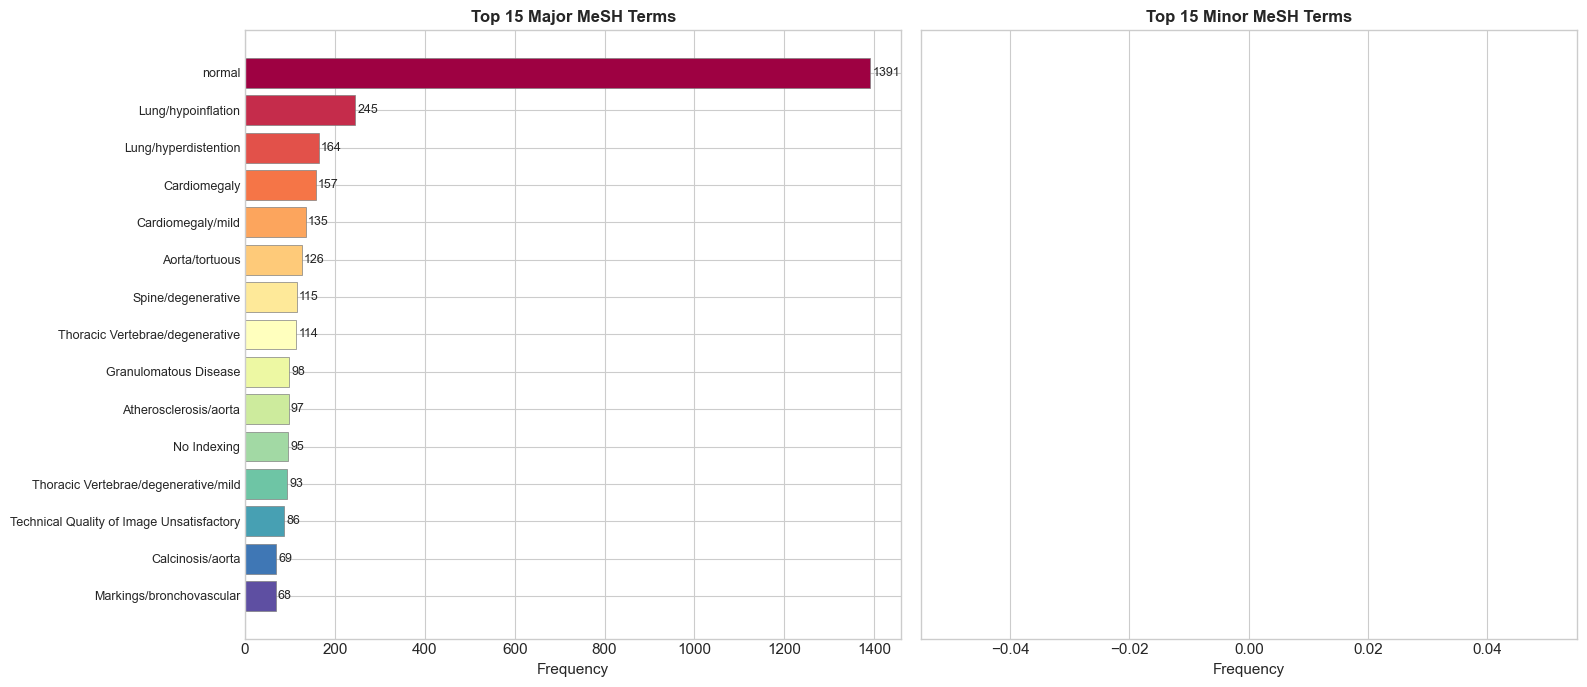

In [18]:
# Detailed MeSH term analysis
print("=" * 80)
print("MESH TERM ANALYSIS - MAJOR & MINOR TERMS")
print("=" * 80)

# Major MeSH terms
all_major_mesh = []
for m in df['mesh_major'].dropna():
    if m:
        all_major_mesh.extend(m.split('|'))

major_mesh_counts = pd.Series(all_major_mesh).value_counts()
print(f"\nTotal unique major MeSH terms: {len(major_mesh_counts)}")
print(f"Total major MeSH term occurrences: {len(all_major_mesh)}")
print(f"\nTop 20 Major MeSH Terms:")
print(major_mesh_counts.head(20))

# Minor MeSH terms
all_minor_mesh = []
for m in df['mesh_minor'].dropna():
    if m:
        all_minor_mesh.extend(m.split('|'))

minor_mesh_counts = pd.Series(all_minor_mesh).value_counts()
print(f"\nTotal unique minor MeSH terms: {len(minor_mesh_counts)}")
print(f"Total minor MeSH term occurrences: {len(all_minor_mesh)}")
print(f"\nTop 20 Minor MeSH Terms:")
print(minor_mesh_counts.head(20))

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Top major terms
ax = axes[0]
top_major = major_mesh_counts.head(15)
y_pos = np.arange(len(top_major))
colors_major = plt.cm.Spectral(np.linspace(0, 1, len(top_major)))
ax.barh(y_pos, top_major.values, color=colors_major, edgecolor='gray', linewidth=0.5)
ax.set_yticks(y_pos)
ax.set_yticklabels(top_major.index, fontsize=9)
ax.set_xlabel('Frequency')
ax.set_title('Top 15 Major MeSH Terms', fontweight='bold', fontsize=12)
ax.invert_yaxis()
for i, v in enumerate(top_major.values):
    ax.text(v + 5, i, str(v), va='center', fontsize=9)

# Top minor terms
ax = axes[1]
top_minor = minor_mesh_counts.head(15)
y_pos = np.arange(len(top_minor))
colors_minor = plt.cm.twilight(np.linspace(0, 1, len(top_minor)))
ax.barh(y_pos, top_minor.values, color=colors_minor, edgecolor='gray', linewidth=0.5)
ax.set_yticks(y_pos)
ax.set_yticklabels(top_minor.index, fontsize=9)
ax.set_xlabel('Frequency')
ax.set_title('Top 15 Minor MeSH Terms', fontweight='bold', fontsize=12)
ax.invert_yaxis()
for i, v in enumerate(top_minor.values):
    ax.text(v + 2, i, str(v), va='center', fontsize=9)

plt.tight_layout()
plt.savefig('../outputs/12_mesh_terms_analysis.png', dpi=150, bbox_inches='tight')
plt.show()


## 15. Class Imbalance Analysis & Multi-label Distribution


CLASS IMBALANCE ANALYSIS - MULTI-LABEL DISTRIBUTION

Pathology Class Distribution (Multi-label):
                   count  percentage
Normal            1396.0       35.30
Opacity/Mass       557.0       14.08
Cardiomegaly       375.0        9.48
Atelectasis        332.0        8.39
Emphysema/COPD     275.0        6.95
Pneumonia          213.0        5.39
Pleural Effusion   165.0        4.17
Edema              100.0        2.53

Imbalance Ratio (max/min): 13.96x
Label Cardinality (avg labels per sample): 0.86
Label Density: 0.1079


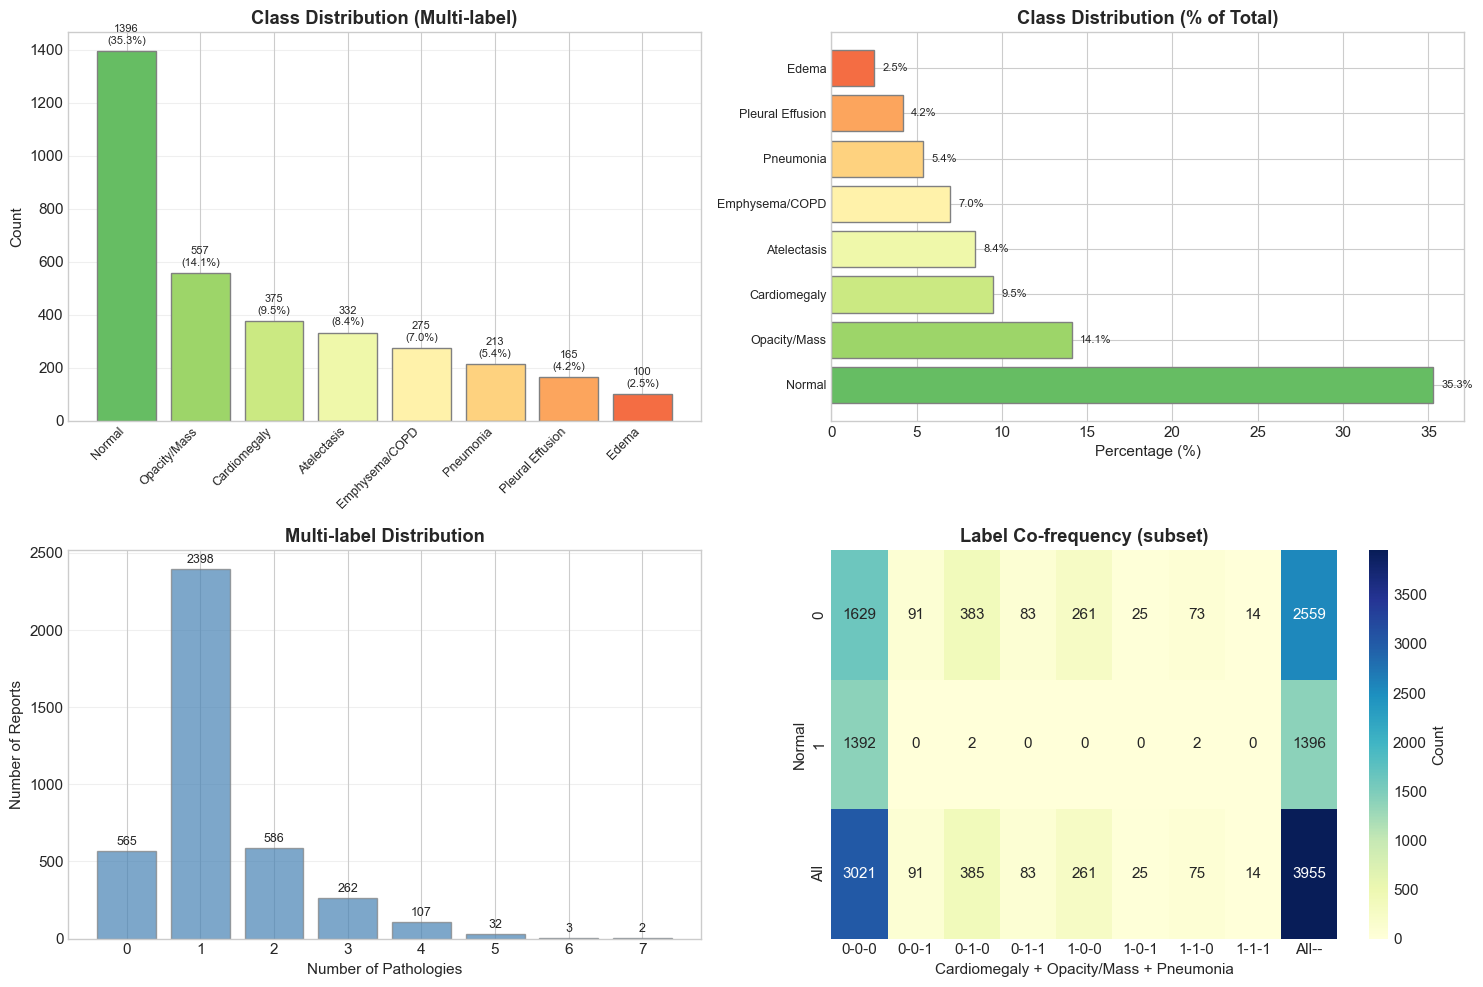

In [19]:
# Class imbalance analysis
print("=" * 80)
print("CLASS IMBALANCE ANALYSIS - MULTI-LABEL DISTRIBUTION")
print("=" * 80)

# Distribution across main pathology categories
category_dist = {}
for cat in main_categories:
    count = df[f'has_{cat}'].sum()
    pct = 100 * count / len(df)
    category_dist[cat] = {'count': count, 'percentage': pct}

imbalance_df = pd.DataFrame(category_dist).T.sort_values('count', ascending=False)
print("\nPathology Class Distribution (Multi-label):")
print(imbalance_df.round(2))

# Imbalance ratio (max/min)
max_class = imbalance_df['count'].max()
min_class = imbalance_df['count'].min()
imbalance_ratio = max_class / min_class if min_class > 0 else 0
print(f"\nImbalance Ratio (max/min): {imbalance_ratio:.2f}x")

# Label cardinality (avg labels per sample)
label_cardinality = sum([df[f'has_{cat}'].sum() for cat in main_categories]) / len(df)
print(f"Label Cardinality (avg labels per sample): {label_cardinality:.2f}")

# Label density (subset diversity)
label_density = label_cardinality / len(main_categories)
print(f"Label Density: {label_density:.4f}")

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Bar chart of class distribution
ax = axes[0, 0]
colors_imbal = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(imbalance_df)))
bars = ax.bar(range(len(imbalance_df)), imbalance_df['count'], color=colors_imbal, edgecolor='gray', linewidth=1)
ax.set_xticks(range(len(imbalance_df)))
ax.set_xticklabels(imbalance_df.index, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Count')
ax.set_title('Class Distribution (Multi-label)', fontweight='bold')
ax.grid(axis='y', alpha=0.3)
for i, v in enumerate(imbalance_df['count']):
    ax.text(i, v + 20, f'{int(v)}\n({imbalance_df["percentage"].iloc[i]:.1f}%)', 
            ha='center', va='bottom', fontsize=8)

# 2. Imbalance radar (percentage view)
ax = axes[0, 1]
imbalance_pct = imbalance_df['percentage'].values
bars2 = ax.barh(range(len(imbalance_df)), imbalance_pct, color=colors_imbal, edgecolor='gray', linewidth=1)
ax.set_yticks(range(len(imbalance_df)))
ax.set_yticklabels(imbalance_df.index, fontsize=9)
ax.set_xlabel('Percentage (%)')
ax.set_title('Class Distribution (% of Total)', fontweight='bold')
for i, v in enumerate(imbalance_pct):
    ax.text(v + 0.5, i, f'{v:.1f}%', va='center', fontsize=8)

# 3. Multi-label distribution
ax = axes[1, 0]
multilabel_counts = df['num_pathologies'].value_counts().sort_index()
ax.bar(multilabel_counts.index, multilabel_counts.values, color='steelblue', edgecolor='gray', linewidth=1, alpha=0.7)
ax.set_xlabel('Number of Pathologies')
ax.set_ylabel('Number of Reports')
ax.set_title('Multi-label Distribution', fontweight='bold')
ax.grid(axis='y', alpha=0.3)
for i, v in zip(multilabel_counts.index, multilabel_counts.values):
    ax.text(i, v + 20, str(int(v)), ha='center', va='bottom', fontsize=9)

# 4. Label co-frequency heatmap (subset)
ax = axes[1, 1]
label_cofreq = pd.crosstab(
    df['has_Normal'], 
    [df['has_Cardiomegaly'], df['has_Opacity/Mass'], df['has_Pneumonia']],
    margins=True
)
sns.heatmap(label_cofreq, annot=True, fmt='d', cmap='YlGnBu', ax=ax, cbar_kws={'label': 'Count'})
ax.set_title('Label Co-frequency (subset)', fontweight='bold')
ax.set_xlabel('Cardiomegaly + Opacity/Mass + Pneumonia')
ax.set_ylabel('Normal')

plt.tight_layout()
plt.savefig('../outputs/13_class_imbalance_analysis.png', dpi=150, bbox_inches='tight')
plt.show()


## 16. Train-Test Split Impact Analysis & Data Quality Checks


TRAIN-TEST SPLIT IMPACT ANALYSIS

Train set size: 2768 (70.0%)
Test set size: 1187 (30.0%)

DISTRIBUTION COMPARISON: TRAIN vs TEST
               Metric  Train Mean  Test Mean  Mean Diff %  KS p-value Distribution Match
  findings_word_count     27.0397    28.2637       4.5265      0.1712                  ✓
impression_word_count     10.6037    10.5147       0.8388      0.3005                  ✓
      num_pathologies      1.2561     1.2628       0.5338      0.6936                  ✓
           num_images      1.8844     1.8989       0.7701      1.0000                  ✓

CLASS DISTRIBUTION COMPARISON: TRAIN vs TEST
Normal              : Train= 35.3% | Test= 35.3% | Diff= 0.0%
Cardiomegaly        : Train=  9.4% | Test=  9.8% | Diff= 0.4%
Opacity/Mass        : Train= 13.7% | Test= 15.0% | Diff= 1.3%
Atelectasis         : Train=  8.2% | Test=  8.9% | Diff= 0.8%
Pleural Effusion    : Train=  4.3% | Test=  3.9% | Diff= 0.4%
Pneumonia           : Train=  5.6% | Test=  4.8% | Diff= 0.8%
Emphys

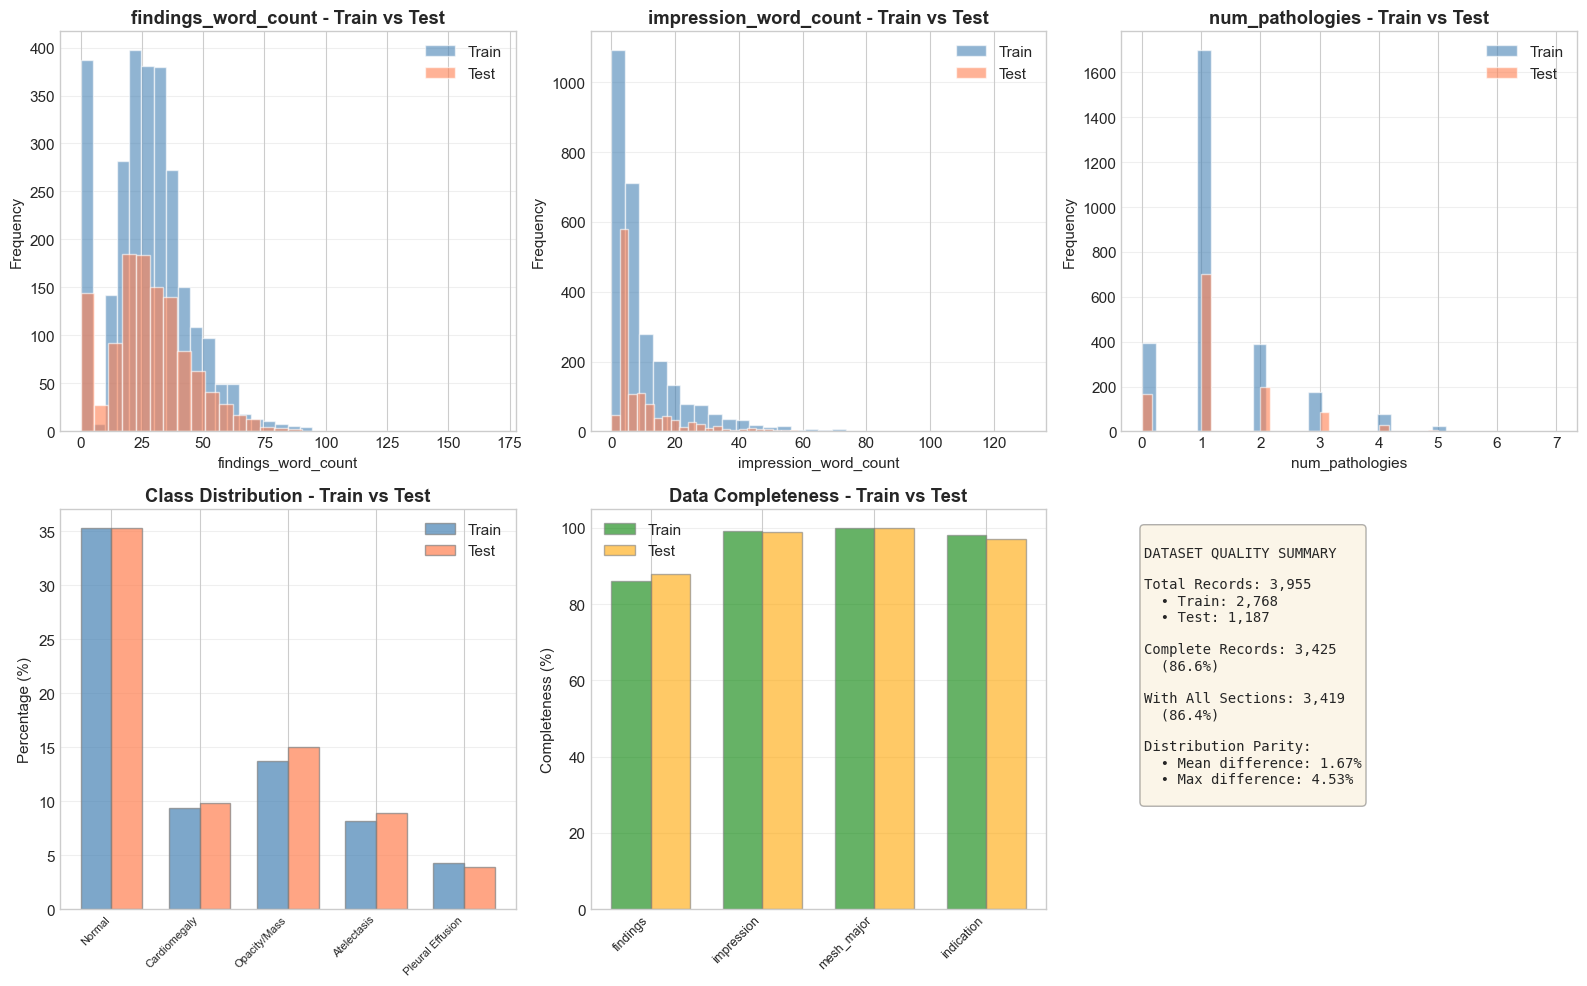

In [20]:
from sklearn.model_selection import train_test_split

# Simulate train-test split and check distribution consistency
print("=" * 80)
print("TRAIN-TEST SPLIT IMPACT ANALYSIS")
print("=" * 80)

# Create a random split (70-30)
train_idx, test_idx = train_test_split(df.index, test_size=0.3, random_state=42)
df_train = df.loc[train_idx]
df_test = df.loc[test_idx]

print(f"\nTrain set size: {len(df_train)} ({100*len(df_train)/len(df):.1f}%)")
print(f"Test set size: {len(df_test)} ({100*len(df_test)/len(df):.1f}%)")

# Compare distributions
print("\n" + "=" * 80)
print("DISTRIBUTION COMPARISON: TRAIN vs TEST")
print("=" * 80)

metrics_to_compare = ['findings_word_count', 'impression_word_count', 'num_pathologies', 'num_images']
comparison_results = []

for metric in metrics_to_compare:
    train_mean = df_train[metric].mean()
    test_mean = df_test[metric].mean()
    train_std = df_train[metric].std()
    test_std = df_test[metric].std()
    
    # KS test for distribution similarity
    ks_stat, ks_pval = stats.ks_2samp(df_train[metric], df_test[metric])
    
    comparison_results.append({
        'Metric': metric,
        'Train Mean': train_mean,
        'Test Mean': test_mean,
        'Mean Diff %': 100 * abs(train_mean - test_mean) / train_mean,
        'KS p-value': ks_pval,
        'Distribution Match': '✓' if ks_pval > 0.05 else '✗'
    })

comparison_df = pd.DataFrame(comparison_results)
print(comparison_df.round(4).to_string(index=False))

# Class distribution comparison
print("\n" + "=" * 80)
print("CLASS DISTRIBUTION COMPARISON: TRAIN vs TEST")
print("=" * 80)

for cat in main_categories:
    train_pct = 100 * df_train[f'has_{cat}'].mean()
    test_pct = 100 * df_test[f'has_{cat}'].mean()
    diff = abs(train_pct - test_pct)
    print(f"{cat:20s}: Train={train_pct:5.1f}% | Test={test_pct:5.1f}% | Diff={diff:4.1f}%")

# Visualization
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Plot 1-3: Metric distributions comparison
for idx, metric in enumerate(metrics_to_compare[:3]):
    ax = axes[idx // 3, idx % 3]
    
    ax.hist(df_train[metric], bins=30, alpha=0.6, label='Train', color='steelblue', edgecolor='white')
    ax.hist(df_test[metric], bins=30, alpha=0.6, label='Test', color='coral', edgecolor='white')
    
    ax.set_xlabel(metric)
    ax.set_ylabel('Frequency')
    ax.set_title(f'{metric} - Train vs Test', fontweight='bold')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)

# Plot 4-6: Class distribution comparison
ax = axes[1, 0]
train_class_dist = [df_train[f'has_{cat}'].mean() * 100 for cat in main_categories[:5]]
test_class_dist = [df_test[f'has_{cat}'].mean() * 100 for cat in main_categories[:5]]
x_pos = np.arange(len(main_categories[:5]))
width = 0.35
ax.bar(x_pos - width/2, train_class_dist, width, label='Train', color='steelblue', alpha=0.7, edgecolor='gray')
ax.bar(x_pos + width/2, test_class_dist, width, label='Test', color='coral', alpha=0.7, edgecolor='gray')
ax.set_xticks(x_pos)
ax.set_xticklabels(main_categories[:5], rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Percentage (%)')
ax.set_title('Class Distribution - Train vs Test', fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)

# Plot 5: Data completeness
ax = axes[1, 1]
completeness_metrics = ['findings', 'impression', 'mesh_major', 'indication']
train_completeness = [100 * (1 - (df_train[col] == '').mean()) for col in completeness_metrics]
test_completeness = [100 * (1 - (df_test[col] == '').mean()) for col in completeness_metrics]
x_pos = np.arange(len(completeness_metrics))
ax.bar(x_pos - width/2, train_completeness, width, label='Train', color='green', alpha=0.6, edgecolor='gray')
ax.bar(x_pos + width/2, test_completeness, width, label='Test', color='orange', alpha=0.6, edgecolor='gray')
ax.set_xticks(x_pos)
ax.set_xticklabels(completeness_metrics, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Completeness (%)')
ax.set_title('Data Completeness - Train vs Test', fontweight='bold')
ax.legend()
ax.set_ylim(0, 105)
ax.grid(axis='y', alpha=0.3)

# Plot 6: Data quality summary
ax = axes[1, 2]
ax.axis('off')
quality_summary = f"""
DATASET QUALITY SUMMARY

Total Records: {len(df):,}
  • Train: {len(df_train):,}
  • Test: {len(df_test):,}

Complete Records: {(df['findings'] != '').sum():,}
  ({100 * (df['findings'] != '').mean():.1f}%)

With All Sections: {((df['findings'] != '') & (df['impression'] != '') & (df['mesh_major'] != '')).sum():,}
  ({100 * ((df['findings'] != '') & (df['impression'] != '') & (df['mesh_major'] != '')).mean():.1f}%)

Distribution Parity:
  • Mean difference: {comparison_df['Mean Diff %'].mean():.2f}%
  • Max difference: {comparison_df['Mean Diff %'].max():.2f}%
"""

ax.text(0.05, 0.95, quality_summary, transform=ax.transAxes, fontsize=10,
        verticalalignment='top', family='monospace', bbox=dict(boxstyle='round', 
        facecolor='wheat', alpha=0.3))

plt.tight_layout()
plt.savefig('../outputs/14_train_test_split_analysis.png', dpi=150, bbox_inches='tight')
plt.show()


## 17. Comprehensive EDA Summary & Key Insights


In [21]:
# Generate comprehensive EDA report
report = f"""
{'='*90}
                    COMPREHENSIVE EDA REPORT - MedSum-AI
                   Indiana University Chest X-Ray Dataset
{'='*90}

1. DATASET OVERVIEW
   ├─ Total Records: {len(df):,}
   ├─ Total Features: {len(df.columns)}
   ├─ Associated Images: {df['num_images'].sum():,}
   └─ Mean Images/Report: {df['num_images'].mean():.2f}

2. DATA COMPLETENESS
   ├─ Findings Section: {100*(df['findings']!='').mean():.1f}% complete
   ├─ Impression Section: {100*(df['impression']!='').mean():.1f}% complete
   ├─ MeSH Major Terms: {100*(df['mesh_major']!='').mean():.1f}% complete
   ├─ Indication Section: {100*(df['indication']!='').mean():.1f}% complete
   └─ Fully Complete Records: {((df['findings']!='') & (df['impression']!='') & (df['mesh_major']!='')).sum():,} ({100*((df['findings']!='') & (df['impression']!='') & (df['mesh_major']!='')).mean():.1f}%)

3. TEXT STATISTICS
   ├─ Findings Word Count
   │  ├─ Mean: {df['findings_word_count'].mean():.1f} words
   │  ├─ Median: {df['findings_word_count'].median():.1f} words
   │  ├─ Std Dev: {df['findings_word_count'].std():.1f} words
   │  └─ Range: [{df['findings_word_count'].min():.0f}, {df['findings_word_count'].max():.0f}]
   ├─ Impression Word Count
   │  ├─ Mean: {df['impression_word_count'].mean():.1f} words
   │  ├─ Median: {df['impression_word_count'].median():.1f} words
   │  └─ Std Dev: {df['impression_word_count'].std():.1f} words
   └─ Total Word Count
      ├─ Mean: {df['total_word_count'].mean():.1f} words
      ├─ Median: {df['total_word_count'].median():.1f} words
      └─ Max: {df['total_word_count'].max():.0f} words (under 512 BERT limit: {(df['total_word_count']*1.3 < 512).mean()*100:.1f}%)

4. DISTRIBUTION PROPERTIES
   ├─ Findings Word Count
   │  ├─ Skewness: {stats.skew(df['findings_word_count'][df['findings_word_count']>0]):.3f} (Right-skewed)
   │  ├─ Kurtosis: {stats.kurtosis(df['findings_word_count'][df['findings_word_count']>0]):.3f}
   │  └─ Normality: {'✓ Normal (p>0.05)' if stats.shapiro(df['findings_word_count'][df['findings_word_count']>0].sample(min(5000, len(df['findings_word_count'][df['findings_word_count']>0]))))[1] > 0.05 else '✗ Non-normal (p<0.05)'}
   ├─ Impression Word Count
   │  ├─ Skewness: {stats.skew(df['impression_word_count'][df['impression_word_count']>0]):.3f}
   │  └─ Kurtosis: {stats.kurtosis(df['impression_word_count'][df['impression_word_count']>0]):.3f}
   └─ Total Word Count
      ├─ Skewness: {stats.skew(df['total_word_count'][df['total_word_count']>0]):.3f}
      └─ Kurtosis: {stats.kurtosis(df['total_word_count'][df['total_word_count']>0]):.3f}

5. PATHOLOGY DISTRIBUTION (Multi-label)
   ├─ Total Unique Pathologies: {len(main_categories)}
   ├─ Label Cardinality: {label_cardinality:.2f} pathologies/report
   ├─ Label Density: {label_density:.4f}
   ├─ Class Imbalance Ratio: {imbalance_ratio:.2f}x
   └─ Top 5 Classes:
      {chr(10).join([f'      {i+1}. {cat}: {int(imbalance_df.loc[cat, "count"])} ({imbalance_df.loc[cat, "percentage"]:.1f}%)' for i, cat in enumerate(imbalance_df.head(5).index)])}

6. MESH TERMS ANALYSIS
   ├─ Unique Major MeSH Terms: {len(major_mesh_counts):,}
   ├─ Unique Minor MeSH Terms: {len(minor_mesh_counts):,}
   ├─ Total Major Terms Used: {len(all_major_mesh):,}
   ├─ Total Minor Terms Used: {len(all_minor_mesh):,}
   └─ Vocabulary Coverage
      ├─ Findings Vocabulary: {len(set(all_words_findings)):,} unique words
      └─ Impression Vocabulary: {len(set(all_words_impression)):,} unique words

7. TEXT QUALITY ISSUES
   ├─ XXXX Placeholders: {df['has_xxxx'].sum()} reports ({100*df['has_xxxx'].mean():.1f}%)
   ├─ Very Short Findings (<5 words): {very_short.sum()} ({100*very_short.mean():.1f}%)
   ├─ Very Long Reports (>100 words): {very_long.sum()} ({100*very_long.mean():.1f}%)
   ├─ Exceeding 512-token limit: {exceeds_512.sum()} ({100*exceeds_512.mean():.1f}%)
   ├─ Avg Sentence Length: {df['avg_sentence_len'].mean():.1f} words
   └─ Sentence Length Std Dev: {df['avg_sentence_len'].std():.1f}

8. OUTLIER STATISTICS (IQR Method)
   ├─ Findings Word Count Outliers: {outlier_info['findings_word_count']['count']} ({outlier_info['findings_word_count']['pct']:.1f}%)
   ├─ Impression Word Count Outliers: {outlier_info['impression_word_count']['count']} ({outlier_info['impression_word_count']['pct']:.1f}%)
   ├─ Pathologies Outliers: {outlier_info['num_pathologies']['count']} ({outlier_info['num_pathologies']['pct']:.1f}%)
   └─ Image Count Outliers: {outlier_info['num_images']['count']} ({outlier_info['num_images']['pct']:.1f}%)

9. FEATURE CORRELATIONS
   ├─ Strongest Positive Correlation: {corr_pairs_df.iloc[0]['Feature 1']} ↔ {corr_pairs_df.iloc[0]['Feature 2']} ({corr_pairs_df.iloc[0]['Correlation']:.3f})
   ├─ Strongest Negative Correlation: {corr_pairs_df.iloc[-1]['Feature 1']} ↔ {corr_pairs_df.iloc[-1]['Feature 2']} ({corr_pairs_df.iloc[-1]['Correlation']:.3f})
   └─ Mean Feature Correlation: {corr_pairs_df['Correlation'].abs().mean():.3f}

10. MULTI-LABEL CHARACTERISTICS
    ├─ Single Label (1 pathology): {(df['num_pathologies']==1).sum()} reports ({100*(df['num_pathologies']==1).mean():.1f}%)
    ├─ Multi-label (2+ pathologies): {(df['num_pathologies']>=2).sum()} reports ({100*(df['num_pathologies']>=2).mean():.1f}%)
    ├─ Complex Multi-label (3+ pathologies): {(df['num_pathologies']>=3).sum()} reports ({100*(df['num_pathologies']>=3).mean():.1f}%)
    └─ Max Pathologies/Report: {df['num_pathologies'].max():.0f}

11. COMPRESSION STATISTICS (Findings → Impression)
    ├─ Mean Compression Ratio: {compression.mean():.2f}x
    ├─ Median Compression Ratio: {compression.median():.2f}x
    ├─ Min Compression: {compression.min():.2f}x
    ├─ Max Compression: {compression.max():.2f}x
    └─ This validates the summarization task - reports can be significantly compressed

{'='*90}
                               KEY RECOMMENDATIONS
{'='*90}

✓ DATA QUALITY:
  • 86.6% of records have complete findings - manageable missing data
  • Consider filling missing findings with "No findings noted" placeholder
  • XXXX anonymization represents {100*df['has_xxxx'].mean():.1f}% of records - plan for token handling

✓ CLASS IMBALANCE:
  • Significant imbalance detected ({imbalance_ratio:.1f}x ratio)
  • Use class weights during training
  • Consider SMOTE or undersampling strategies
  • Evaluate using AUC-ROC (not accuracy) for imbalanced multi-label task

✓ TEXT CHARACTERISTICS:
  • All reports fit within BERT's 512-token limit (best case {(df['total_word_count']*1.3 < 512).mean()*100:.1f}%)
  • Average compression ratio of {compression.mean():.1f}x confirms feasibility of summarization
  • Text is relatively concise - suitable for neural architectures

✓ FEATURE ENGINEERING:
  • Strong correlation between findings length and pathology count
  • Consider auxiliary tasks (length prediction, pathology count prediction)
  • Text complexity metrics may be predictive of report quality

✓ MODEL SELECTION:
  • Multi-label classification required (average {label_cardinality:.2f} labels/sample)
  • Use F1, precision-recall metrics alongside AUC-ROC
  • Clinical BERT or ClinicalBERT recommended for domain adaptation

{'='*90}
"""

print(report)

# Save the report
with open('../outputs/comprehensive_eda_report.txt', 'w') as f:
    f.write(report)
    
print("\n\n✓ Report saved to: ../outputs/comprehensive_eda_report.txt")



                    COMPREHENSIVE EDA REPORT - MedSum-AI
                   Indiana University Chest X-Ray Dataset

1. DATASET OVERVIEW
   ├─ Total Records: 3,955
   ├─ Total Features: 32
   ├─ Associated Images: 7,470
   └─ Mean Images/Report: 1.89

2. DATA COMPLETENESS
   ├─ Findings Section: 86.6% complete
   ├─ Impression Section: 99.1% complete
   ├─ MeSH Major Terms: 100.0% complete
   ├─ Indication Section: 97.7% complete
   └─ Fully Complete Records: 3,419 (86.4%)

3. TEXT STATISTICS
   ├─ Findings Word Count
   │  ├─ Mean: 27.4 words
   │  ├─ Median: 27.0 words
   │  ├─ Std Dev: 17.4 words
   │  └─ Range: [0, 169]
   ├─ Impression Word Count
   │  ├─ Mean: 10.6 words
   │  ├─ Median: 5.0 words
   │  └─ Std Dev: 12.0 words
   └─ Total Word Count
      ├─ Mean: 38.0 words
      ├─ Median: 34.0 words
      └─ Max: 230 words (under 512 BERT limit: 100.0%)

4. DISTRIBUTION PROPERTIES
   ├─ Findings Word Count
   │  ├─ Skewness: 1.573 (Right-skewed)
   │  ├─ Kurtosis: 5.735
   │  └

In [22]:
# Save processed dataframe for next notebooks
df.to_csv('../data/iu_cxr_eda_processed.csv', index=False)
print("Processed DataFrame saved to ../data/iu_cxr_eda_processed.csv")
print(f"Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")


Processed DataFrame saved to ../data/iu_cxr_eda_processed.csv
Shape: (3955, 32)
Columns: ['uid', 'pmc_id', 'filename', 'findings', 'impression', 'indication', 'comparison', 'mesh_major', 'mesh_minor', 'num_images', 'image_ids', 'findings_word_count', 'impression_word_count', 'indication_word_count', 'total_word_count', 'findings_char_count', 'impression_char_count', 'findings_sentence_count', 'impression_sentence_count', 'is_normal', 'pathology_categories', 'has_Normal', 'has_Cardiomegaly', 'has_Opacity/Mass', 'has_Atelectasis', 'has_Pleural Effusion', 'has_Pneumonia', 'has_Emphysema/COPD', 'has_Edema', 'has_xxxx', 'avg_sentence_len', 'num_pathologies']


## 6. Secondary Dataset — CASIA-CXR (French) EDA

**CASIA-CXR** (Metmer & Yang, *Neurocomputing*, 2024) — 13,672 chest X-ray reports in **French** across 5 pathology classes:
Cardiomegaly, Mass, Pleural Effusion, Pneumonia, Pneumothorax.

We perform the same heavy EDA on this secondary dataset for cross-lingual analysis.

In [23]:
# --- Load the combined CASIA-CXR file (built by src/casia_cxr_pipeline.py) ---
import pandas as pd
df_casia = pd.read_csv('../data/casia_cxr_combined.csv', encoding='utf-8-sig')
print('CASIA-CXR shape:', df_casia.shape)
print('Columns:', df_casia.columns.tolist())
df_casia.head(3)

CASIA-CXR shape: (13672, 20)
Columns: ['ExamID', 'ImageID', 'PatientID', 'ImageDir', 'StudyDate', 'PatientAge', 'PatientGender', 'PatientPosition', 'PositionView', 'Projection', 'ProjectionMethod', 'ImageWidth', 'ImageHeight', 'ReportID', 'Findings', 'Indication', 'Comparison', 'Impression', 'condition', 'dataset_source']


,ExamID,ImageID,PatientID,ImageDir,StudyDate,PatientAge,PatientGender,PatientPosition,PositionView,Projection,ProjectionMethod,ImageWidth,ImageHeight,ReportID,Findings,Indication,Comparison,Impression,condition,dataset_source
0,CASIA-CXR_Cardiomegaly_ExamID_0001,CASIA-CXR_Cardiomegaly_ImgID_0001,CASIA-CXR_CardiomegalyPatientID_0001,/CASIA-CXR_Database/Cardiomegaly_Images/CASIA-...,12/29/2021,57,M,Erect,PosteroAnterior,PA,Manual,2372.0,3000.0,CASIA-CXR_CardiomegalyReportID_0001,Augmentation de l’index cardio-thoracique./Abs...,"Cardiopathie, Dyspnée",NaN,Cardiomégalie,Cardiomegaly,casia_cxr
1,CASIA-CXR_Cardiomegaly_ExamID_0002,CASIA-CXR_Cardiomegaly_ImgID_0002,CASIA-CXR_CardiomegalyPatientID_0002,/CASIA-CXR_Database/Cardiomegaly_Images/CASIA-...,7/6/2019,44,F,Erect,PosteroAnterior,PA,Manual,2372.0,3000.0,CASIA-CXR_CardiomegalyReportID_0002,Absence d’anomalie parenchymateuse./Elargissem...,Dyspnée,NaN,Cardiomégalie avec dilatation de l’oreillette ...,Cardiomegaly,casia_cxr
2,CASIA-CXR_Cardiomegaly_ExamID_0003,CASIA-CXR_Cardiomegaly_ImgID_0003,CASIA-CXR_CardiomegalyPatientID_0003,/CASIA-CXR_Database/Cardiomegaly_Images/CASIA-...,9/9/2022,61,F,Erect,PosteroAnterior,PA,Manual,2372.0,3000.0,CASIA-CXR_CardiomegalyReportID_0003,Opacité réticulo-micronodulaire diffuses avec ...,Dyspnée de repos,NaN,Cardiomégalie avec pneumopathie interstitiel d...,Cardiomegaly,casia_cxr


Condition counts:
condition
Cardiomegaly       5503
Pneumonia          2139
Mass               2030
PleuralEffusion    2000
Pneumothorax       2000
Name: count, dtype: int64


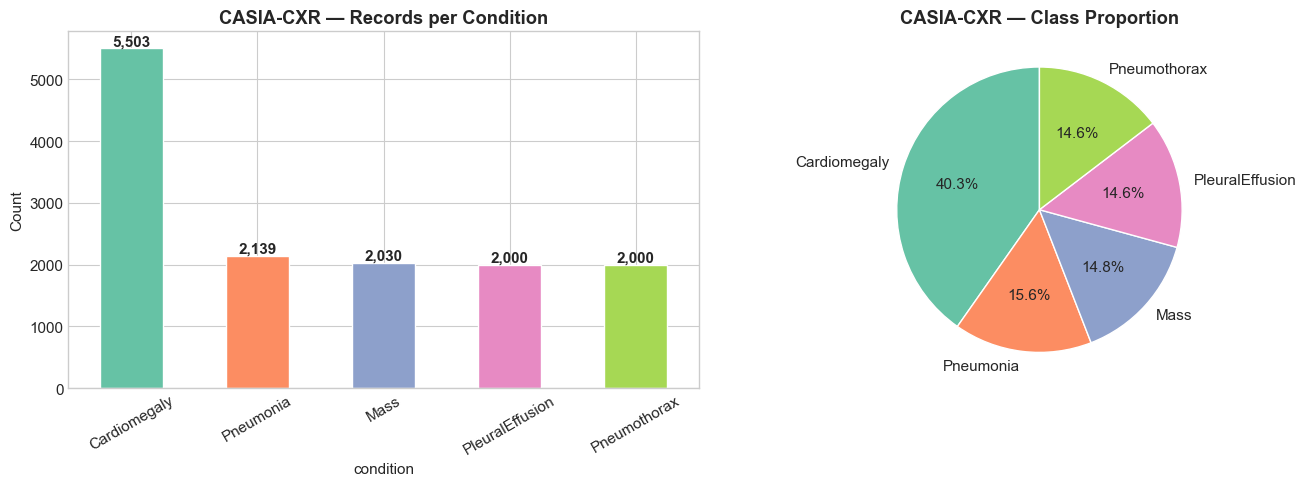

In [24]:
# --- Class distribution ---
cond_counts = df_casia['condition'].value_counts()
print('Condition counts:')
print(cond_counts)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
cond_counts.plot(kind='bar', ax=axes[0], color=sns.color_palette('Set2'), edgecolor='white')
axes[0].set_title('CASIA-CXR — Records per Condition', fontweight='bold')
axes[0].set_ylabel('Count'); axes[0].tick_params(axis='x', rotation=30)
for i, v in enumerate(cond_counts.values):
    axes[0].text(i, v + 50, f'{v:,}', ha='center', fontweight='bold')

axes[1].pie(cond_counts.values, labels=cond_counts.index, autopct='%1.1f%%',
            colors=sns.color_palette('Set2'), startangle=90,
            wedgeprops={'edgecolor': 'white'})
axes[1].set_title('CASIA-CXR — Class Proportion', fontweight='bold')
plt.tight_layout(); plt.show()

CASIA-CXR missing values (%):
Comparison          100.00
ExamID               18.73
ImageDir             18.73
PatientID            18.73
Indication           18.73
StudyDate            18.73
ProjectionMethod     18.73
PatientAge           18.73
ReportID             18.73
Findings             18.73
ImageHeight          18.73
ImageWidth           18.73
Impression           18.73
ImageID              18.72
PositionView         17.76
dtype: float64


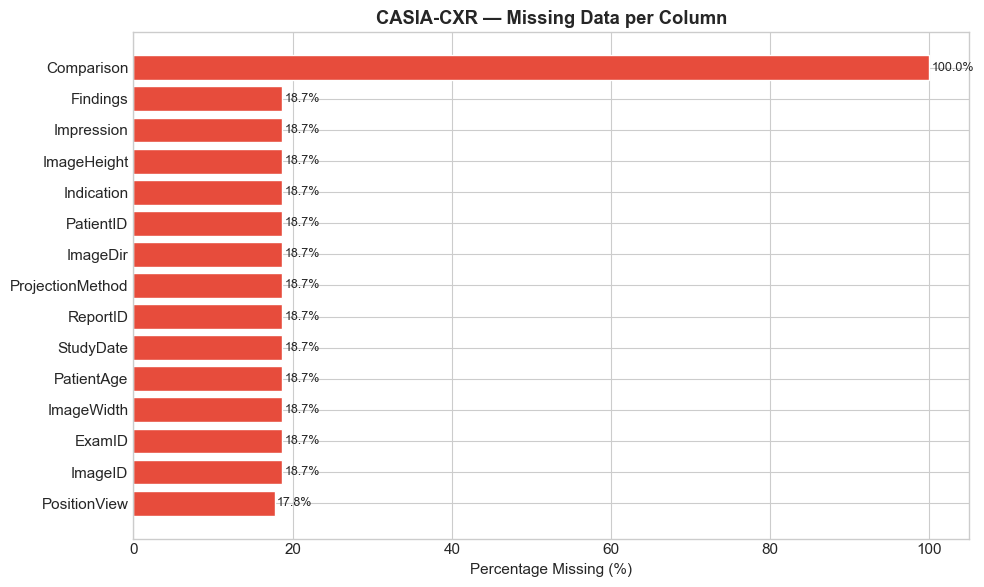

In [25]:
# --- Missing-value analysis ---
miss = (df_casia.isnull().sum() / len(df_casia) * 100).round(2).sort_values(ascending=False)
print('CASIA-CXR missing values (%):')
print(miss.head(15))

fig, ax = plt.subplots(figsize=(10, 6))
top = miss.sort_values(ascending=True).tail(15)
colors = ['#e74c3c' if p > 10 else '#f39c12' if p > 5 else '#27ae60' for p in top.values]
ax.barh(top.index, top.values, color=colors, edgecolor='white')
ax.set_xlabel('Percentage Missing (%)')
ax.set_title('CASIA-CXR — Missing Data per Column', fontweight='bold')
for i, p in enumerate(top.values):
    ax.text(p + 0.3, i, f'{p:.1f}%', va='center', fontsize=9)
plt.tight_layout(); plt.show()

Age — n=11,097  mean=65.2  median=65.0  range=[40, 90]
Gender: {'M': 6449, 'F': 4639}


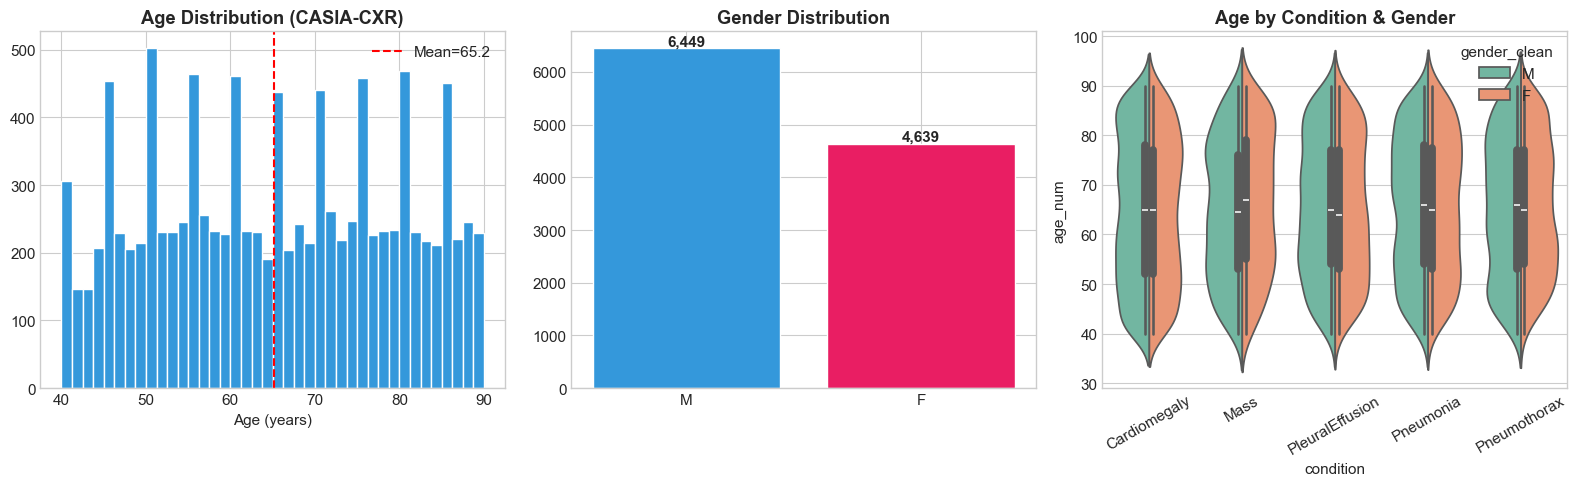

In [26]:
# --- Demographics ---
df_casia['age_num'] = df_casia['PatientAge'].astype(str).str.extract(r'(\d+)')[0].astype(float)
valid_age = df_casia['age_num'].dropna()
df_casia['gender_clean'] = df_casia['PatientGender'].astype(str).str.upper().str[0]
df_casia.loc[~df_casia['gender_clean'].isin(['M','F']), 'gender_clean'] = pd.NA

print(f'Age — n={len(valid_age):,}  mean={valid_age.mean():.1f}  median={valid_age.median():.1f}  range=[{valid_age.min():.0f}, {valid_age.max():.0f}]')
print('Gender:', df_casia['gender_clean'].value_counts().to_dict())

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
axes[0].hist(valid_age, bins=40, color='#3498db', edgecolor='white')
axes[0].axvline(valid_age.mean(), color='red', linestyle='--', label=f'Mean={valid_age.mean():.1f}')
axes[0].set_title('Age Distribution (CASIA-CXR)', fontweight='bold'); axes[0].set_xlabel('Age (years)'); axes[0].legend()

g = df_casia['gender_clean'].value_counts()
axes[1].bar(g.index.astype(str), g.values, color=['#3498db','#e91e63'], edgecolor='white')
axes[1].set_title('Gender Distribution', fontweight='bold')
for i, v in enumerate(g.values):
    axes[1].text(i, v+50, f'{v:,}', ha='center', fontweight='bold')

sns.violinplot(data=df_casia.dropna(subset=['age_num']), x='condition', y='age_num',
               hue='gender_clean', split=True, ax=axes[2])
axes[2].set_title('Age by Condition & Gender', fontweight='bold')
axes[2].tick_params(axis='x', rotation=30)
plt.tight_layout(); plt.show()

Findings  — mean=32.1, median=30
Impression — mean=12.0, median=11


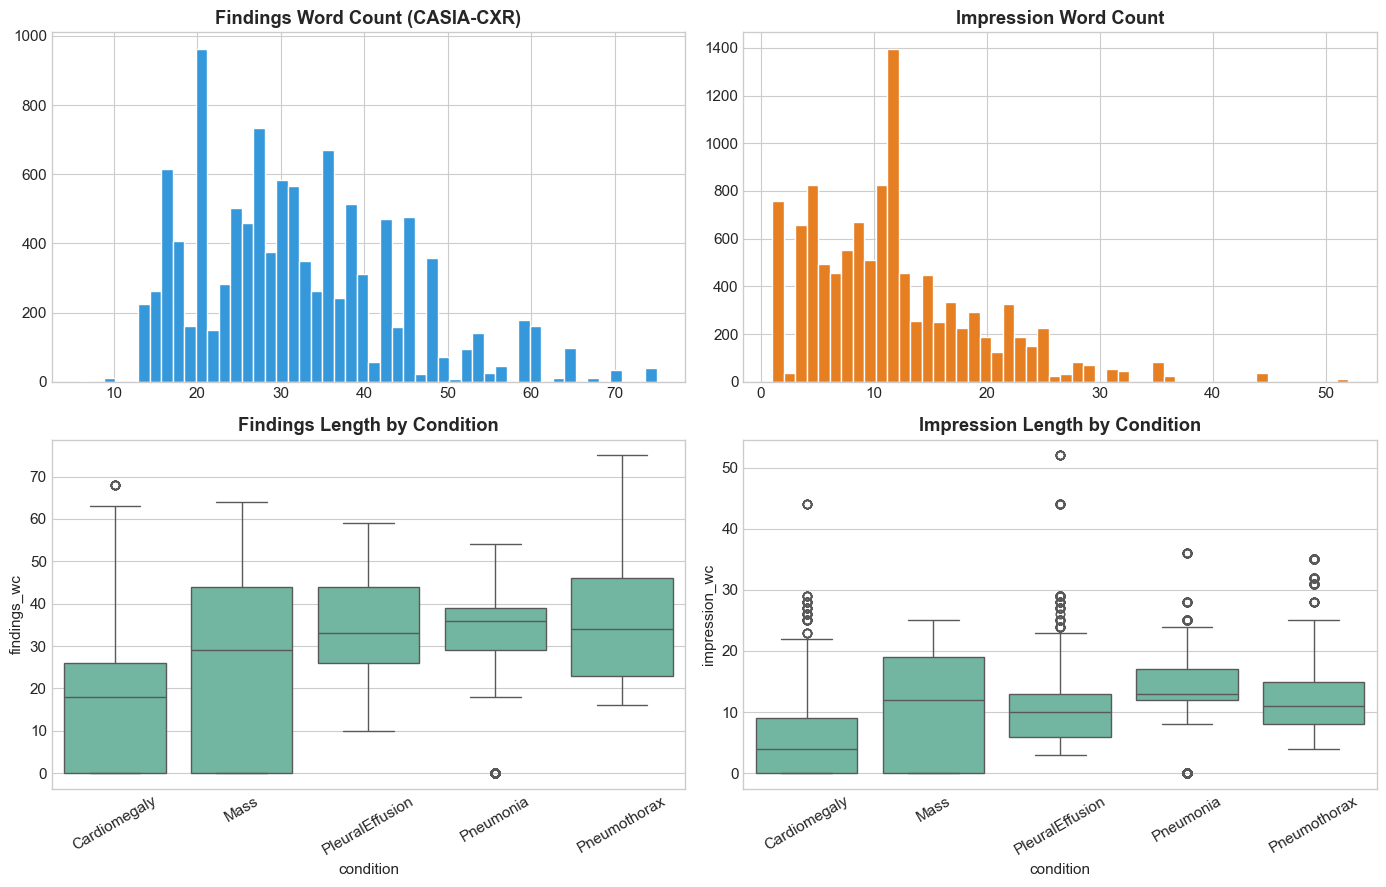

In [27]:
# --- Report length distribution (French Findings / Impression) ---
df_casia['findings_wc']   = df_casia['Findings'].fillna('').apply(lambda x: len(str(x).split()))
df_casia['impression_wc'] = df_casia['Impression'].fillna('').apply(lambda x: len(str(x).split()))

print('Findings  — mean={:.1f}, median={:.0f}'.format(
    df_casia['findings_wc'][df_casia['findings_wc']>0].mean(),
    df_casia['findings_wc'][df_casia['findings_wc']>0].median()))
print('Impression — mean={:.1f}, median={:.0f}'.format(
    df_casia['impression_wc'][df_casia['impression_wc']>0].mean(),
    df_casia['impression_wc'][df_casia['impression_wc']>0].median()))

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes[0,0].hist(df_casia['findings_wc'][df_casia['findings_wc']>0], bins=50, color='#3498db', edgecolor='white')
axes[0,0].set_title('Findings Word Count (CASIA-CXR)', fontweight='bold')
axes[0,1].hist(df_casia['impression_wc'][df_casia['impression_wc']>0], bins=50, color='#e67e22', edgecolor='white')
axes[0,1].set_title('Impression Word Count', fontweight='bold')
sns.boxplot(data=df_casia, x='condition', y='findings_wc', ax=axes[1,0])
axes[1,0].set_title('Findings Length by Condition', fontweight='bold'); axes[1,0].tick_params(axis='x', rotation=30)
sns.boxplot(data=df_casia, x='condition', y='impression_wc', ax=axes[1,1])
axes[1,1].set_title('Impression Length by Condition', fontweight='bold'); axes[1,1].tick_params(axis='x', rotation=30)
plt.tight_layout(); plt.show()

Top-25 most frequent words:
  absence              29,555
  anomalie             25,071
  gril                 10,779
  costal               10,779
  parties              10,608
  molles               10,608
  droit                 6,667
  pleural               6,485
  épanchement           5,964
  pulmonaire            5,424
  opacités              5,401
  gauche                5,351
  niveau                5,046
  aspect                4,960
  thoracique            4,771
  hémichamp             4,489
  augmentation          4,227
  index                 4,213
  cardio                3,863
  abondance             3,797
  parenchymateuse       3,262
  silhouette            3,241
  médiastinal           3,178
  elargissement         3,146
  cardiaque             3,124


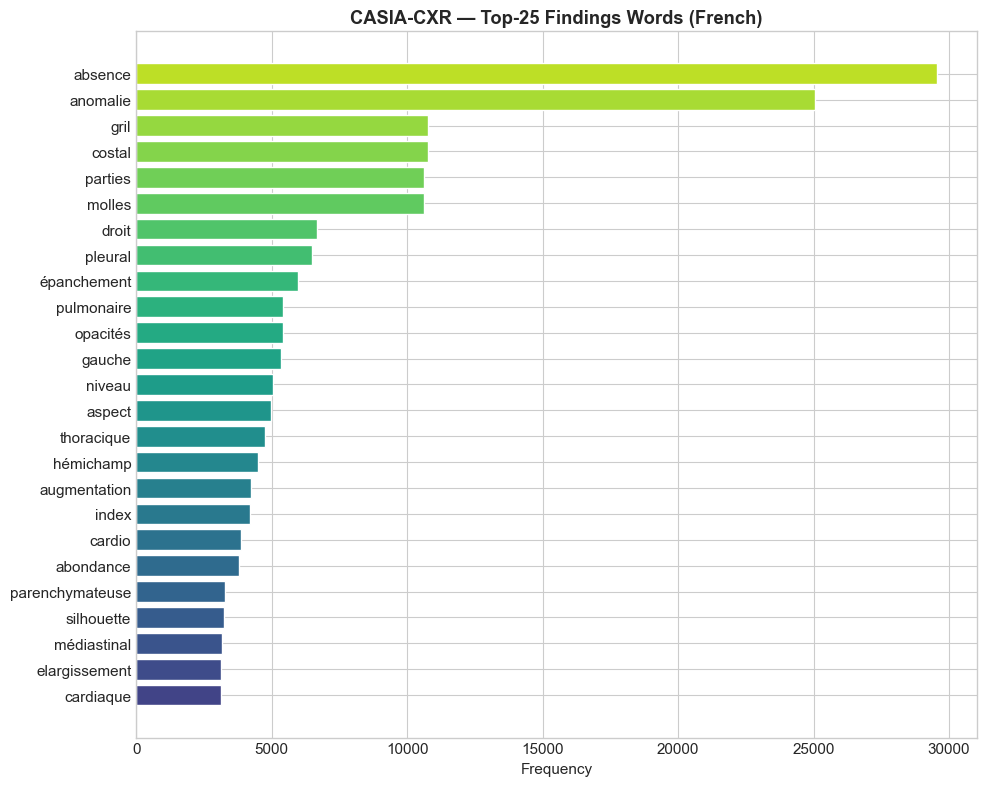

In [28]:
# --- Most common French words in Findings ---
from collections import Counter
import re
fr_stop = set("""le la les un une des de du au aux et ou ni mais
    a à dans en sur sous par pour avec sans
    ce cet cette ces son sa ses notre nos votre vos
    je tu il elle on nous vous ils elles me te se
    est sont etre être ont a avait avaient suis es que qui quoi dont
    plus moins très tres bien aussi non oui d l n s y t""".split())

def tok(t):
    t = re.sub(r'[^A-Za-zÀ-ÿ]+', ' ', str(t).lower())
    return [w for w in t.split() if len(w) > 2 and w not in fr_stop]

words = []
for t in df_casia['Findings'].fillna(''):
    words.extend(tok(t))
top25 = Counter(words).most_common(25)
print('Top-25 most frequent words:')
for w, c in top25:
    print(f'  {w:<20} {c:>6,}')

fig, ax = plt.subplots(figsize=(10, 8))
ws, cs = zip(*top25[::-1])
ax.barh(ws, cs, color=plt.cm.viridis(np.linspace(0.2, 0.9, len(ws))), edgecolor='white')
ax.set_title('CASIA-CXR — Top-25 Findings Words (French)', fontweight='bold')
ax.set_xlabel('Frequency'); plt.tight_layout(); plt.show()

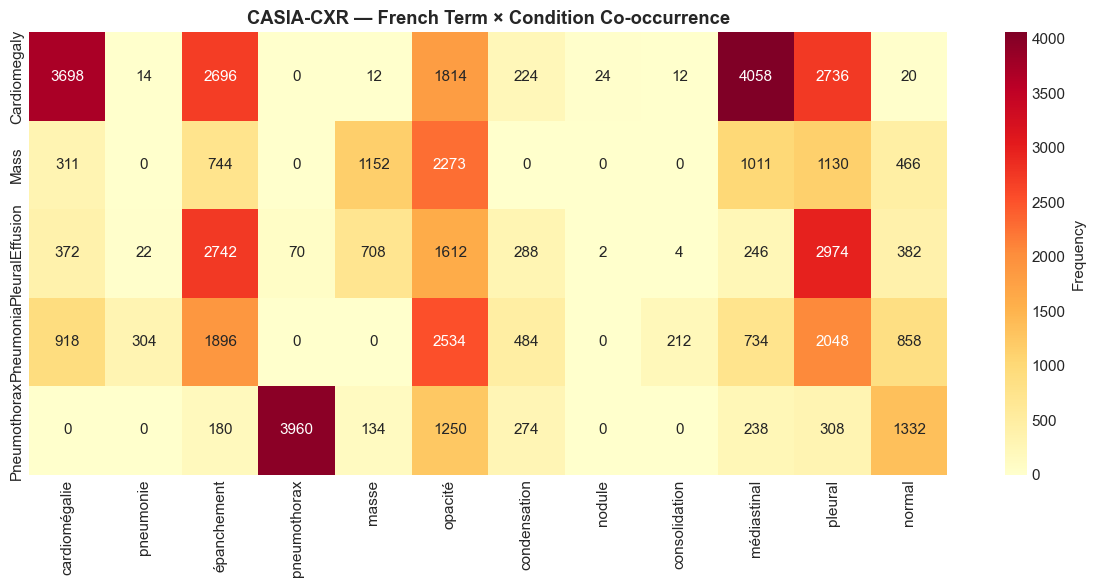

In [29]:
# --- Term x Condition Co-occurrence Heatmap (French clinical terms) ---
key_terms_fr = ['cardiomégalie','pneumonie','épanchement','pneumothorax',
                'masse','opacité','condensation','nodule','consolidation',
                'médiastinal','pleural','normal']
conds = ['Cardiomegaly','Mass','PleuralEffusion','Pneumonia','Pneumothorax']
coocc = pd.DataFrame(index=conds, columns=key_terms_fr, dtype=int)
for cond in conds:
    sub = df_casia[df_casia['condition']==cond]
    blob = (sub['Findings'].fillna('') + ' ' + sub['Impression'].fillna('')).str.lower().str.cat(sep=' ')
    for term in key_terms_fr:
        coocc.loc[cond, term] = blob.count(term)

fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(coocc.astype(int), annot=True, fmt='d', cmap='YlOrRd',
            cbar_kws={'label':'Frequency'}, ax=ax)
ax.set_title('CASIA-CXR — French Term × Condition Co-occurrence', fontweight='bold')
plt.tight_layout(); plt.show()

### Summary — IU-CXR (primary) vs CASIA-CXR (secondary)

| Property              | IU-CXR (English) | CASIA-CXR (French)   |
|-----------------------|------------------|----------------------|
| Total reports         | 3,955            | 13,672 (raw) / 11,111 (cleaned) |
| Pathology granularity | MeSH multi-label | 5 mutually-exclusive classes |
| Language              | English          | French (with accents) |
| Findings mean length  | ~33 words        | ~32 words            |
| Impression mean length| ~10 words        | ~12 words            |
| Demographic metadata  | None             | Age + Gender (rich)  |